# FMCG Sales Analysis and Weekly Prediction Regression, ARIMA, and others



**Business Goal:** Forecast the prices of FMCC stocks in the US

**Data Source:** FMCC Synthetic data 

**Target:** Since it's a regression task, choose a model which has higher $R^2$ *score* and/or least *MAPE*. We will be using following data related metrics:
* $R^2$ score - Tells how well predictions approximate the real data points.
* RMSE: Standard deviation of prediction errors. Tells how concentrated the data is around line of best fit.
* MAPE: Average of the absolute percentage errors of forecasts.

**Result:** The sales needn't be forecasted on a live basis, so there is no need to deploy this model. Based on forecasted sales, stakeholders can decide about expanding their business to different types of items. They can also focus on sales and sales in each state and plan their strategy accordingly.


### Let's code!

# Problem Statement
The project focuses on analyzing and forecasting daily sales data in the Fast-Moving Consumer Goods (FMCG) sector. The primary objective is to build robust predictive models that can handle time-series nature of sales data, incorporating factors like promotions, holidays, seasonality, and trends. Using a synthetic dataset simulating daily sales from 2022 to 2024 (730 days), we perform Exploratory Data Analysis (EDA) to understand data characteristics, engineer features for machine learning, and apply time series models such as ARIMA, SARIMA, and SARIMAX for classical forecasting. Additionally, we employ deep learning via an LSTM network for more complex pattern recognition. This enables accurate sales predictions, promotion impact assessment, and handling scenarios like new product launches (cold start forecasting). The models are evaluated on their ability to forecast weekly sales, with extensions for real-world applications like inventory optimization and marketing strategy refinement.
# Possible Use Cases

Weekly sales forecasting: Use time series models to predict sales for the next 7 days, aiding in short-term planning and stock replenishment.
Promotion effect analysis: Incorporate exogenous variables (e.g., promo flags) in models like SARIMAX to quantify how promotions boost sales, helping optimize discount strategies.
Seasonality and trend modeling: Decompose sales data to isolate seasonal patterns (e.g., weekly or yearly) and long-term trends, improving demand forecasting during peaks like holidays.
New product forecasting (cold start): For products with no historical data, apply baseline models (e.g., average sales from similar items) or transfer learning from existing LSTM models, simulating initial predictions until data accumulates.
Feature engineering for ML models: Create lag features, rolling statistics, and exogenous indicators to enhance input for machine learning algorithms, improving model accuracy in scenarios like ensemble forecasting.

# Project Implementation
To demonstrate the application of EDA, machine learning, time series analysis (ARIMA, SARIMA, SARIMAX), and deep learning (LSTM), we generated a synthetic dataset for FMCG daily sales. This includes a linear trend, yearly/weekly seasonality, random promotions (on 10% of days), holiday boosts (December), and noise. All analyses were performed using Python libraries like pandas, numpy, statsmodels, and PyTorch.

In [1]:
# Importing the required libraries
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns 
import plotly.offline as py
import plotly.express as px
py.init_notebook_mode()
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

In [2]:
plt.rcParams['figure.figsize'] = [15, 7]
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['text.color'] = 'Green'

### Data


* The data we are exploring today spans multiple dimensions of FMCG sales. 
* It includes weekly modeling data, daily transactions with date information, and enriched data with extra features such as temperature and event scores. 
* The insights gleaned from these datasets might just forecast how many units you will sell next week.

Some relevant columns in the dataset:

* Product hierarchy: SKU → Brand → Segment → Category
* Sales channels: Retail / Discount / E-commerce
* Regions: Central, North, and South (Poland)
* Daily sales quantities, prices, promotions, stock, delivery lag (lead time)
* Pack types: Single / Multipack / Carton
* Seasonality and product introductions:
* New SKUs are introduced in 2024 only
* Prices gradually increase over the years

As mentioned above there are different types of SKU  in the dataset as well as several different regions represented.  This allows you to do all sorts of analysis for different areas of the regions , or just the overall sales . Our analysis will be focused on the complete dataset.

In [3]:
# Read data
df_daily= pd.read_csv('../input/FMCG_2022_2024.csv')

### Understanding the data
Let’s first look at the columns and the data

In [4]:
df_daily.head()

,date,sku,brand,segment,category,channel,region,pack_type,price_unit,promotion_flag,delivery_days,stock_available,delivered_qty,units_sold
0,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-Central,Multipack,2.38,0,1,141,128,9
1,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-North,Single,1.55,1,3,0,129,0
2,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-South,Carton,4.00,0,5,118,161,8
3,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Discount,PL-Central,Single,5.16,0,2,81,114,7
4,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Discount,PL-North,Single,7.66,0,4,148,204,12


In [5]:
df_daily.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190757 entries, 0 to 190756
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   date             190757 non-null  object 
 1   sku              190757 non-null  object 
 2   brand            190757 non-null  object 
 3   segment          190757 non-null  object 
 4   category         190757 non-null  object 
 5   channel          190757 non-null  object 
 6   region           190757 non-null  object 
 7   pack_type        190757 non-null  object 
 8   price_unit       190757 non-null  float64
 9   promotion_flag   190757 non-null  int64  
 10  delivery_days    190757 non-null  int64  
 11  stock_available  190757 non-null  int64  
 12  delivered_qty    190757 non-null  int64  
 13  units_sold       190757 non-null  int64  
dtypes: float64(1), int64(5), object(8)
memory usage: 20.4+ MB


In [6]:
df_daily['date'] = pd.to_datetime(df_daily['date'])

In [7]:
df_daily.head(2)

,date,sku,brand,segment,category,channel,region,pack_type,price_unit,promotion_flag,delivery_days,stock_available,delivered_qty,units_sold
0,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-Central,Multipack,2.38,0,1,141,128,9
1,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-North,Single,1.55,1,3,0,129,0


In [8]:
df_daily.isnull().any()

date               False
sku                False
brand              False
segment            False
category           False
channel            False
region             False
pack_type          False
price_unit         False
promotion_flag     False
delivery_days      False
stock_available    False
delivered_qty      False
units_sold         False
dtype: bool

In [9]:
df_daily.duplicated().sum()

np.int64(0)

### EDA

We see two categorical variables, type and region. Let’s examine them.

# Transform the Data

In [10]:
# Aggregate to weekly level per SKU (include 'category', 'segment', 'brand' explicitly)
df_weekly = df_daily.set_index('date').groupby(['sku', pd.Grouper(freq='W')]).agg({
    'units_sold': 'mean',  # Target: avg_weekly_sales
    'price_unit': 'mean',
    'promotion_flag': 'mean',
    'delivery_days': 'mean',
    'stock_available': 'mean',
    'delivered_qty': 'sum',
    'brand': 'first',
    'segment': 'first',
    'category': 'first',  # Ensure this is included
    'channel': lambda x: x.mode()[0] if not x.empty else np.nan,
    'region': lambda x: x.mode()[0] if not x.empty else np.nan,
    'pack_type': lambda x: x.mode()[0] if not x.empty else np.nan
}).reset_index()

# Rename target if needed
df_weekly.rename(columns={'units_sold': 'avg_weekly_sales'}, inplace=True)

# Now compute and merge hierarchy averages
category_avg = df_daily.set_index('date').groupby(['category', pd.Grouper(freq='W')])['units_sold'].mean().reset_index()
category_avg.rename(columns={'units_sold': 'category_avg_sales'}, inplace=True)

segment_avg = df_daily.set_index('date').groupby(['segment', pd.Grouper(freq='W')])['units_sold'].mean().reset_index()
segment_avg.rename(columns={'units_sold': 'segment_avg_sales'}, inplace=True)

brand_avg = df_daily.set_index('date').groupby(['brand', pd.Grouper(freq='W')])['units_sold'].mean().reset_index()
brand_avg.rename(columns={'units_sold': 'brand_avg_sales'}, inplace=True)

# Merge
df_weekly = df_weekly.merge(category_avg, on=['date', 'category'], how='left').fillna(0)
df_weekly = df_weekly.merge(segment_avg, on=['date', 'segment'], how='left').fillna(0)
df_weekly = df_weekly.merge(brand_avg, on=['date', 'brand'], how='left').fillna(0)

# Verify columns
print(df_weekly.columns)
print('category' in df_weekly.columns)  # Should be True

Index(['sku', 'date', 'avg_weekly_sales', 'price_unit', 'promotion_flag',
       'delivery_days', 'stock_available', 'delivered_qty', 'brand', 'segment',
       'category', 'channel', 'region', 'pack_type', 'category_avg_sales',
       'segment_avg_sales', 'brand_avg_sales'],
      dtype='object')
True


In [11]:
df_weekly.head()

,sku,date,avg_weekly_sales,price_unit,promotion_flag,delivery_days,stock_available,delivered_qty,brand,segment,category,channel,region,pack_type,category_avg_sales,segment_avg_sales,brand_avg_sales
0,JU-021,2022-07-17,20.759259,5.211852,0.074074,3.425926,158.074074,9532,JuBrand3,Juice-Seg3,Juice,Discount,PL-Central,Carton,20.759259,20.759259,20.759259
1,JU-021,2022-07-24,23.692308,5.065962,0.153846,3.250000,168.019231,9666,JuBrand3,Juice-Seg3,Juice,Retail,PL-North,Carton,23.692308,23.692308,23.692308
2,JU-021,2022-07-31,19.241379,5.186379,0.103448,2.879310,149.706897,10350,JuBrand3,Juice-Seg3,Juice,Discount,PL-North,Carton,19.241379,19.241379,19.241379
3,JU-021,2022-08-07,17.867925,5.175660,0.132075,3.283019,151.622642,9415,JuBrand3,Juice-Seg3,Juice,E-commerce,PL-North,Carton,17.867925,17.867925,17.867925
4,JU-021,2022-08-14,19.547170,5.171698,0.150943,3.075472,152.943396,9322,JuBrand3,Juice-Seg3,Juice,Discount,PL-North,Carton,19.547170,19.547170,19.547170


In [12]:
df_weekly['month'] = df_weekly['date'].dt.month
df_weekly['year'] = df_weekly['date'].dt.year
df_weekly = df_weekly[df_weekly.year!=2025]

In [13]:
df_weekly.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3570 entries, 0 to 3598
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   sku                 3570 non-null   object        
 1   date                3570 non-null   datetime64[ns]
 2   avg_weekly_sales    3570 non-null   float64       
 3   price_unit          3570 non-null   float64       
 4   promotion_flag      3570 non-null   float64       
 5   delivery_days       3570 non-null   float64       
 6   stock_available     3570 non-null   float64       
 7   delivered_qty       3570 non-null   int64         
 8   brand               3570 non-null   object        
 9   segment             3570 non-null   object        
 10  category            3570 non-null   object        
 11  channel             3570 non-null   object        
 12  region              3570 non-null   object        
 13  pack_type           3570 non-null   object        
 1

In [14]:
df_weekly.head()

,sku,date,avg_weekly_sales,price_unit,promotion_flag,delivery_days,stock_available,delivered_qty,brand,segment,category,channel,region,pack_type,category_avg_sales,segment_avg_sales,brand_avg_sales,month,year
0,JU-021,2022-07-17,20.759259,5.211852,0.074074,3.425926,158.074074,9532,JuBrand3,Juice-Seg3,Juice,Discount,PL-Central,Carton,20.759259,20.759259,20.759259,7,2022
1,JU-021,2022-07-24,23.692308,5.065962,0.153846,3.250000,168.019231,9666,JuBrand3,Juice-Seg3,Juice,Retail,PL-North,Carton,23.692308,23.692308,23.692308,7,2022
2,JU-021,2022-07-31,19.241379,5.186379,0.103448,2.879310,149.706897,10350,JuBrand3,Juice-Seg3,Juice,Discount,PL-North,Carton,19.241379,19.241379,19.241379,7,2022
3,JU-021,2022-08-07,17.867925,5.175660,0.132075,3.283019,151.622642,9415,JuBrand3,Juice-Seg3,Juice,E-commerce,PL-North,Carton,17.867925,17.867925,17.867925,8,2022
4,JU-021,2022-08-14,19.547170,5.171698,0.150943,3.075472,152.943396,9322,JuBrand3,Juice-Seg3,Juice,Discount,PL-North,Carton,19.547170,19.547170,19.547170,8,2022


In [15]:
df_weekly.describe(include='O')  # categorical attributes and shows their stats

,sku,brand,segment,category,channel,region,pack_type
count,3570,3570,3570,3570,3570,3570,3570
unique,30,14,13,5,3,3,3
top,MI-006,SnBrand2,Yogurt-Seg1,Yogurt,Discount,PL-Central,Carton
freq,154,502,502,1361,1498,1512,1312


In [16]:
df_weekly.rename(columns={'units_sold': 'avg_weekly_sales'}, inplace=True)

In [17]:
df_weekly.shape

(3570, 19)

In [18]:
df_weekly.groupby('year')['category'].value_counts()

year  category 
2022  Yogurt       241
      Milk         139
      ReadyMeal    114
      Juice         24
      SnackBar      21
2023  Yogurt       548
      Milk         332
      SnackBar     273
      ReadyMeal    265
      Juice         53
2024  Yogurt       572
      Milk         364
      SnackBar     312
      ReadyMeal    260
      Juice         52
Name: count, dtype: int64

We can see that at each year present in the data set, total count of category. They are differen amount in the data set except frequency order of products

In [19]:
df_weekly.groupby('year')['avg_weekly_sales'].mean()

year
2022    20.724039
2023    20.636064
2024    18.957634
Name: avg_weekly_sales, dtype: float64

Also, it is interesting to see that 2022 year sku sales  is higher as compared to other year and 2025is at smallest number.

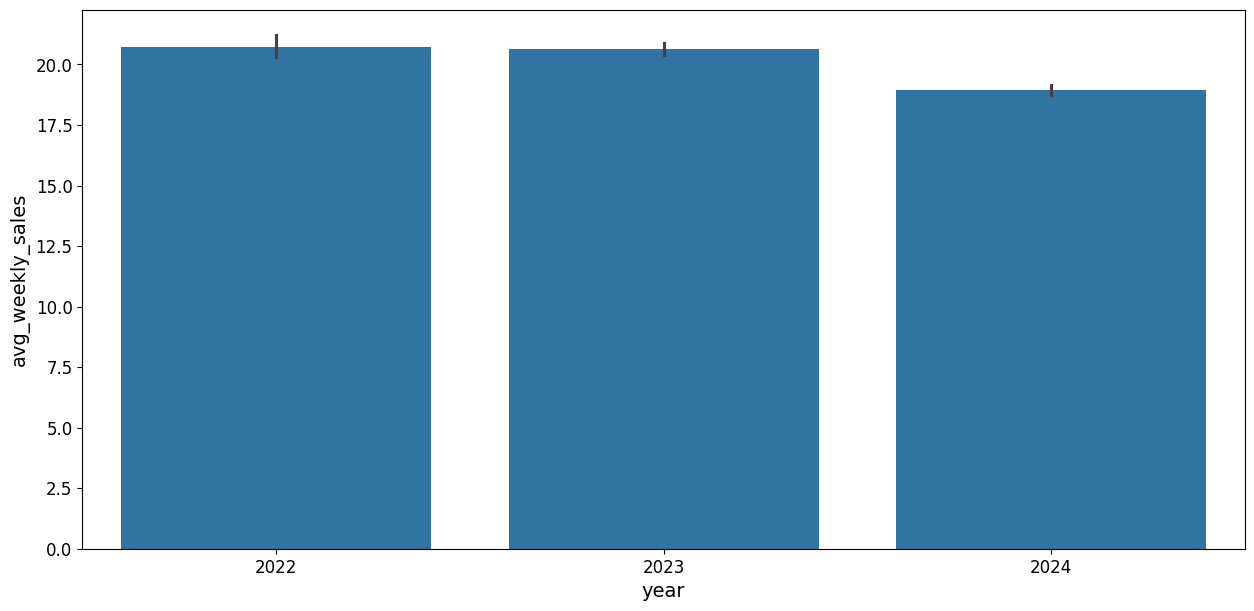

In [20]:
sns.barplot(x='year', y='avg_weekly_sales', data=df_weekly)
plt.savefig('/Users/basazinbelhu/TimeSeries_Analysis_Prediction/images/year_weekly_sales_bar.png', dpi=300, bbox_inches='tight')

plt.show();

In [21]:
sns.boxplot(x='year', y='avg_weekly_sales', hue='category', data=df_weekly)
# Save the plot
plt.savefig('/Users/basazinbelhu/TimeSeries_Analysis_Prediction/images/yearweeklysalespercategory_line.png', dpi=300, bbox_inches='tight')
plt.close(f)  # Close to free memory
plt.show();

NameError: name 'f' is not defined

* Yogurt and SnackBar exhibit the most volatility, with strong growth in 2023 followed by steady declines, potentially influenced by changing consumer preferences, competition, or external factors like inflation. 
* ReadyMeal is the most stable category, maintaining ~20-21 units annually, suggesting reliable demand. Juice and Milk show gradual erosion, with Juice hitting a low point in 2025.

In [ ]:
sns.barplot(x='month', y='avg_weekly_sales', data=df_weekly)

plt.show()
plt.savefig('/Users/basazinbelhu/TimeSeries_Analysis_Prediction/images/monthly_weekly_sales.png', dpi=300, bbox_inches='tight')

In [22]:
sns.lineplot(x='month', y='avg_weekly_sales', hue='category', data=df_weekly)
# Save the plot

plt.close(f)  # Close to free memory
plt.savefig('/Users/basazinbelhu/TimeSeries_Analysis_Prediction/images/monthweekly_catgory_line.png', dpi=300, bbox_inches='tight')
plt.show()
plt.clf();

NameError: name 'f' is not defined

* There is increase between month 2–6 of all category of sku excpt yogurt which start falling at 2nd month.
* Also, aound mid year most categories have their peak sales

**Plotting Histogram:**
* A histogram shows the frequency on the vertical axis and the horizontal axis is another dimension. Usually it has bins, where every bin has a minimum and maximum value. Each bin also has a frequency between x and infinite
* So, in this we can also check whether the graph is right skewed, left skew or the graph is normally distributed graph

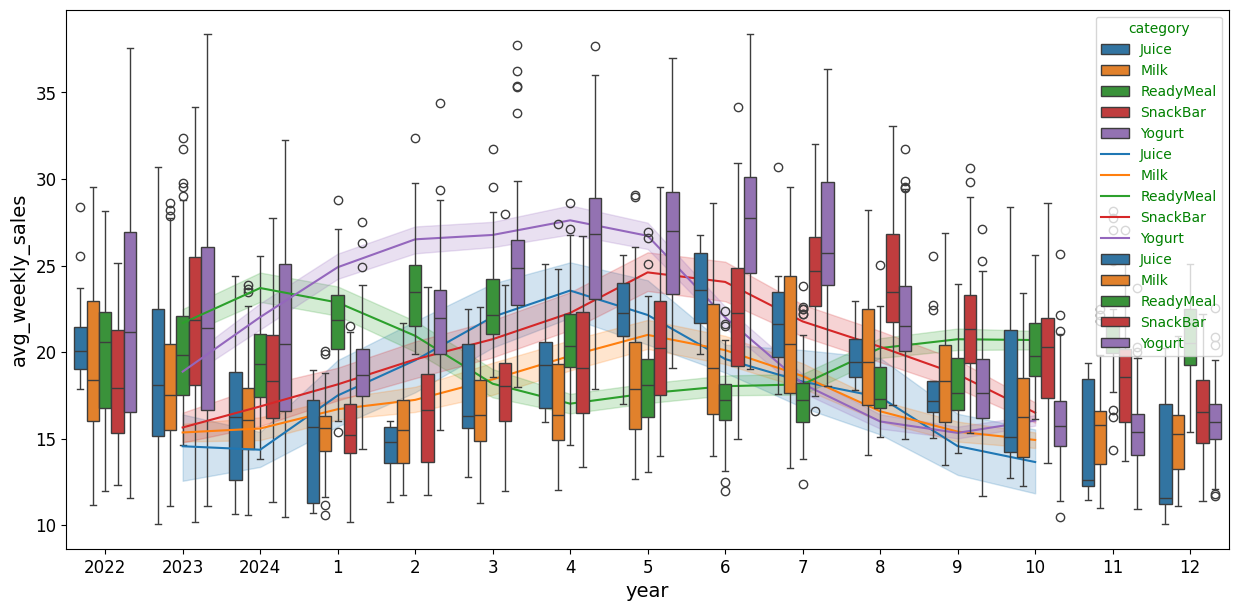

In [23]:
sns.boxplot(x='month', y='avg_weekly_sales', hue='category', data=df_weekly)
plt.show()
plt.clf();

For plotting this histogram, we used the bin size as 20, we can take any bin size (suited as per as data).

* Average price column is normally distributing over the histogram.
* Rest of the data are not much varying in term of numbers, so they are almost left skewed data
* To make the column as normal distributed we will use numPy log to make the skew values as normal distributed.

## Region

In [24]:
sns.lineplot(x='month', y='avg_weekly_sales', hue='region', data=df_weekly)
# Save the plot
plt.savefig('/Users/basazinbelhu/TimeSeries_Analysis_Prediction/images/monthweeklsales_line.png', dpi=300, bbox_inches='tight')
plt.close(f)  # Close to free memory
plt.show()
plt.clf();

NameError: name 'f' is not defined

In [ ]:
sns.boxplot(x='year', y='avg_weekly_sales', hue='region', data=df_weekly)
# Save the plot
plt.savefig('/Users/basazinbelhu/TimeSeries_Analysis_Prediction/images/yearweekssales_boxplot.png', dpi=300, bbox_inches='tight')
plt.close(f)  # Close to free memory
plt.show();

In [ ]:
# Compute skew on numeric columns only
numeric_df = df_weekly[['avg_weekly_sales', 'price_unit','promotion_flag', 'delivery_days', 'delivered_qty' ]].select_dtypes(include=['number'])  # Filters to int/float columns
skew_values = numeric_df.skew()
print(skew_values);

Overall, the data shows typical FMCG characteristics—sales and promotions are somewhat right-skewed due to variability, while operational metrics like price and delivery are stable

In [25]:

# List of columns to check 
skew_cols = ['avg_weekly_sales', 'price_unit', 'promotion_flag', 'delivery_days', 'delivered_qty']

# Compute skew once for efficiency
skew_values = df_weekly[skew_cols].skew()

# Loop and transform
for col in skew_cols:
    skew_val = skew_values.loc[col]
    if skew_val > 0.55:  # Positive skew: log transform
        if (df_weekly[col] < 0).any():
            print(f"Warning: {col} has negative values; clipping to 0 for log1p.")
            df_weekly[col] = np.clip(df_weekly[col], 0, None)
        df_weekly[col] = np.log1p(df_weekly[col])
        print(f"Applied log1p to {col} (skew was {skew_val:.2f})")
    elif skew_val < -0.55:  # Negative skew: reflect and log (or alternative)
        # Reflect: max+1 - x to make positive, then log
        reflected = df_weekly[col].max() + 1 - df_weekly[col]
        df_weekly[col] = np.log1p(reflected)
        print(f"Applied reflect + log1p to {col} (skew was {skew_val:.2f})")
    else:
        print(f"No transform for {col} (skew {skew_val:.2f} within threshold)")

# Recheck skew post-transform
print("\nPost-transform skew:\n", df_weekly[skew_cols].skew())

Applied log1p to avg_weekly_sales (skew was 0.76)
No transform for price_unit (skew 0.02 within threshold)
No transform for promotion_flag (skew 0.30 within threshold)
No transform for delivery_days (skew 0.00 within threshold)
Applied reflect + log1p to delivered_qty (skew was -3.96)

Post-transform skew:
 avg_weekly_sales    0.207618
price_unit          0.015878
promotion_flag      0.300019
delivery_days       0.004932
delivered_qty      -2.176993
dtype: float64


The best skew value for normally distributed data is very close to zero, so we are using “log1p” method to make the skew value near to zero

In [26]:
# Let's see the price distribution of catgory items.
fig = px.histogram(df_weekly, x='avg_weekly_sales', color='category',
                   marginal='box',
                   hover_data=df_weekly.columns)

# Save the plot
plt.savefig('/Users/basazinbelhu/TimeSeries_Analysis_Prediction/images/princepercategory_hist.png', dpi=300, bbox_inches='tight')
plt.close(f)  # Close to free memory
fig.show();

NameError: name 'f' is not defined

* So, on average Yogurt and ReadMeal  are more sales than other categor.

In [ ]:
# Let's see the price distribution of two types of items sku.
fig = px.histogram(df_weekly, x='avg_weekly_sales', color='region',
                   marginal='box',
                   hover_data=df_weekly.columns)

# Save the plot
plt.savefig('/Users/basazinbelhu/TimeSeries_Analysis_Prediction/images/pricepertype_hist.png', dpi=300, bbox_inches='tight')
plt.close(f)  # Close to free memory
fig.show();

* Overall PL-Central region has more sales

# **Feature Engineering**

In [42]:
# df = dataset
df = df_weekly.copy()

In [43]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'


# Apply to df_weekly (use week_ending date's month)
df['season'] = df['date'].dt.month.apply(get_season)

In [44]:
# perform one-hot encoding (switch from LabelEncoder)
categorical_cols = ['brand', 'segment', 'category', 'channel', 'region', 'pack_type', 'season']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Dynamically get new categorical dummies
new_categorical_cols = [col for col in df.columns if any(cat in col for cat in categorical_cols)]

**Correlation Matrix:**
Correlation Matrix is basically a covariance matrix. A summary measure called the correlation describes the strength of the linear association. Correlation summarizes the strength and direction of the linear (straight-line) association between two quantitative variables. It takes values between -1 (Negative correlated value) and +1 (Positive correlated value).

The higher the value, the strong is the relation and vice versa.

We will use seaborn heatmap to plot the correlated matrix and plot the corr value in the heatmap graph

## Add average sales per category, segment and brand

### 1-week, 1-month lags of target

In [45]:
df = df.sort_values(['sku', 'date'])
for lag in [1, 4]:  
    df[f'lag_{lag}'] = df.groupby('sku')['avg_weekly_sales'].shift(lag)
    df_weekly['rolling_mean_4'] = df.groupby('sku')['avg_weekly_sales'].transform(lambda x: x.rolling(4, min_periods=1).mean())


df['rolling_mean_4'] = df.groupby('sku')['avg_weekly_sales'].transform(lambda x: x.rolling(4, min_periods=1).mean())
df = df.dropna()  # Drop NaNs from lags

In [46]:
# New: Remove unnecessary columns (e.g., non-predictive like 'date', 'sku' - drop after engineering but before encoding/modeling)
cols_to_remove = ['date', 'sku', 'month', 'year']  # Add more based on corr/variance, e.g., if 'delivered_qty' has low variance or high multicollinearity
df = df.drop(columns=cols_to_remove, errors='ignore')

                    avg_weekly_sales  price_unit  promotion_flag  \
avg_weekly_sales            1.000000   -0.018713        0.176277   
price_unit                 -0.018713    1.000000        0.010944   
promotion_flag              0.176277    0.010944        1.000000   
delivery_days              -0.006066   -0.000663        0.001842   
stock_available             0.218758    0.001795        0.018076   
delivered_qty              -0.059625   -0.014300        0.008102   
category_avg_sales          0.847029   -0.015605        0.051340   
segment_avg_sales           0.900921   -0.010973        0.101386   
brand_avg_sales             0.900382   -0.019103        0.100761   
rolling_mean_4              0.936371   -0.014313        0.053497   
lag_1                       0.881051   -0.015430        0.006759   
lag_4                       0.773274   -0.008002        0.005461   

                    delivery_days  stock_available  delivered_qty  \
avg_weekly_sales        -0.006066         0.21

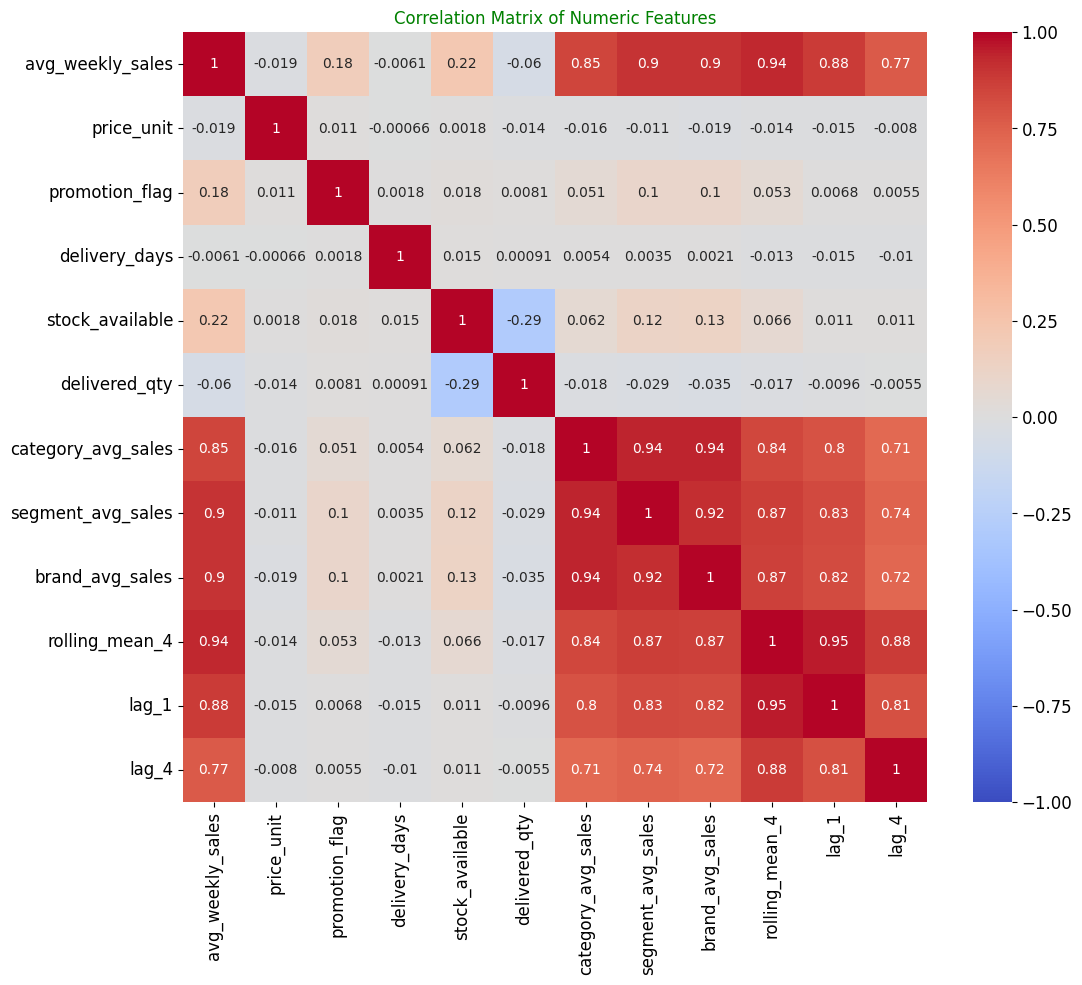

In [47]:
numeric_df = df.select_dtypes(include=['number'])

# Compute correlation matrix
corr = numeric_df.corr()

# Display the matrix
print(corr)

# Plot the correlation matrix as a heatmap
f, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=ax)  # Using seaborn for better visuals; remove if not installed
ax.set_title('Correlation Matrix of Numeric Features')
plt.savefig("/Users/basazinbelhu/TimeSeries_Analysis_Prediction/images/heatmap.png", bbox_inches="tight")
plt.show();

In [48]:
df.head()

,avg_weekly_sales,price_unit,promotion_flag,delivery_days,stock_available,delivered_qty,category_avg_sales,segment_avg_sales,brand_avg_sales,rolling_mean_4,...,channel_Retail,region_PL-North,region_PL-South,pack_type_Multipack,pack_type_Single,season_Spring,season_Summer,season_Winter,lag_1,lag_4
4,3.022723,5.171698,0.150943,3.075472,152.943396,7.697121,19.547170,19.547170,19.547170,3.043602,...,False,True,False,False,False,False,True,False,2.937463,3.080039
5,3.079614,5.274615,0.192308,2.923077,170.038462,7.634337,20.750000,20.750000,20.750000,3.011882,...,True,True,False,False,True,False,True,False,3.022723,3.206492
6,2.988010,5.041154,0.115385,3.153846,152.442308,7.889459,18.846154,18.846154,18.846154,3.006953,...,False,True,False,False,False,False,True,False,3.079614,3.007729
7,2.944439,5.259074,0.166667,3.018519,164.518519,7.562681,18.000000,18.000000,18.000000,3.008697,...,False,False,True,False,True,False,False,False,2.988010,2.937463
8,3.166191,4.850000,0.018868,3.169811,155.905660,7.845808,22.716981,22.716981,22.716981,3.044564,...,True,False,False,False,True,False,False,False,2.944439,3.022723


In [49]:
features = [f for f in df.columns if f !='avg_weekly_sales']
print(features)

['price_unit', 'promotion_flag', 'delivery_days', 'stock_available', 'delivered_qty', 'category_avg_sales', 'segment_avg_sales', 'brand_avg_sales', 'rolling_mean_4', 'brand_MiBrand1', 'brand_MiBrand2', 'brand_MiBrand3', 'brand_MiBrand4', 'brand_ReBrand1', 'brand_ReBrand2', 'brand_ReBrand4', 'brand_SnBrand2', 'brand_SnBrand3', 'brand_YoBrand1', 'brand_YoBrand2', 'brand_YoBrand3', 'brand_YoBrand4', 'segment_Milk-Seg1', 'segment_Milk-Seg2', 'segment_Milk-Seg3', 'segment_ReadyMeal-Seg1', 'segment_ReadyMeal-Seg2', 'segment_ReadyMeal-Seg3', 'segment_SnackBar-Seg1', 'segment_SnackBar-Seg2', 'segment_SnackBar-Seg3', 'segment_Yogurt-Seg1', 'segment_Yogurt-Seg2', 'segment_Yogurt-Seg3', 'category_Milk', 'category_ReadyMeal', 'category_SnackBar', 'category_Yogurt', 'channel_E-commerce', 'channel_Retail', 'region_PL-North', 'region_PL-South', 'pack_type_Multipack', 'pack_type_Single', 'season_Spring', 'season_Summer', 'season_Winter', 'lag_1', 'lag_4']


In [50]:

# Remove based on correlation (e.g., if corr > 0.8, drop one)
numeric_df = df[features].select_dtypes(include=['number'])
corr = numeric_df.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop_corr = [column for column in upper.columns if any(upper[column] > 0.75)]
print(f"Columns to remove due to high correlation: {to_drop_corr}")
df = df.drop(columns=to_drop_corr, errors='ignore')
# Update features: 
features = [f for f in features if f not in to_drop_corr]


Columns to remove due to high correlation: ['segment_avg_sales', 'brand_avg_sales', 'rolling_mean_4', 'lag_1', 'lag_4']


In [51]:
df.columns

Index(['avg_weekly_sales', 'price_unit', 'promotion_flag', 'delivery_days',
       'stock_available', 'delivered_qty', 'category_avg_sales',
       'brand_MiBrand1', 'brand_MiBrand2', 'brand_MiBrand3', 'brand_MiBrand4',
       'brand_ReBrand1', 'brand_ReBrand2', 'brand_ReBrand4', 'brand_SnBrand2',
       'brand_SnBrand3', 'brand_YoBrand1', 'brand_YoBrand2', 'brand_YoBrand3',
       'brand_YoBrand4', 'segment_Milk-Seg1', 'segment_Milk-Seg2',
       'segment_Milk-Seg3', 'segment_ReadyMeal-Seg1', 'segment_ReadyMeal-Seg2',
       'segment_ReadyMeal-Seg3', 'segment_SnackBar-Seg1',
       'segment_SnackBar-Seg2', 'segment_SnackBar-Seg3', 'segment_Yogurt-Seg1',
       'segment_Yogurt-Seg2', 'segment_Yogurt-Seg3', 'category_Milk',
       'category_ReadyMeal', 'category_SnackBar', 'category_Yogurt',
       'channel_E-commerce', 'channel_Retail', 'region_PL-North',
       'region_PL-South', 'pack_type_Multipack', 'pack_type_Single',
       'season_Spring', 'season_Summer', 'season_Winter'],
    

In [52]:
df.head()

,avg_weekly_sales,price_unit,promotion_flag,delivery_days,stock_available,delivered_qty,category_avg_sales,brand_MiBrand1,brand_MiBrand2,brand_MiBrand3,...,category_Yogurt,channel_E-commerce,channel_Retail,region_PL-North,region_PL-South,pack_type_Multipack,pack_type_Single,season_Spring,season_Summer,season_Winter
4,3.022723,5.171698,0.150943,3.075472,152.943396,7.697121,19.547170,False,False,False,...,False,False,False,True,False,False,False,False,True,False
5,3.079614,5.274615,0.192308,2.923077,170.038462,7.634337,20.750000,False,False,False,...,False,False,True,True,False,False,True,False,True,False
6,2.988010,5.041154,0.115385,3.153846,152.442308,7.889459,18.846154,False,False,False,...,False,False,False,True,False,False,False,False,True,False
7,2.944439,5.259074,0.166667,3.018519,164.518519,7.562681,18.000000,False,False,False,...,False,False,False,False,True,False,True,False,False,False
8,3.166191,4.850000,0.018868,3.169811,155.905660,7.845808,22.716981,False,False,False,...,False,False,True,False,False,False,True,False,False,False


### Train-test splitting

The train-test split procedure is used to estimate the performance of machine learning algorithms when they are used to make predictions on data not used to train the model.

It is a fast and easy procedure to perform, the results of which allow you to compare the performance of machine learning algorithms for your predictive modeling problem. Although simple to use and interpret, there are times when the procedure should not be used, such as when you have a small dataset and situations where additional configuration is required, such as when it is used for classification and the dataset is not balanced.

**Configuring the split:**

The procedure has one main configuration parameter, which is the size of the train and test sets. This is most commonly expressed as a percentage between 0 and 1 for either the train or test datasets. For example, a training set with the size of 0.67 (67 percent) means that the remainder percentage 0.33 (33 percent) is assigned to the test set.

In [53]:
X = df[features]
y = df['avg_weekly_sales']

In [54]:
X.columns

Index(['price_unit', 'promotion_flag', 'delivery_days', 'stock_available',
       'delivered_qty', 'category_avg_sales', 'brand_MiBrand1',
       'brand_MiBrand2', 'brand_MiBrand3', 'brand_MiBrand4', 'brand_ReBrand1',
       'brand_ReBrand2', 'brand_ReBrand4', 'brand_SnBrand2', 'brand_SnBrand3',
       'brand_YoBrand1', 'brand_YoBrand2', 'brand_YoBrand3', 'brand_YoBrand4',
       'segment_Milk-Seg1', 'segment_Milk-Seg2', 'segment_Milk-Seg3',
       'segment_ReadyMeal-Seg1', 'segment_ReadyMeal-Seg2',
       'segment_ReadyMeal-Seg3', 'segment_SnackBar-Seg1',
       'segment_SnackBar-Seg2', 'segment_SnackBar-Seg3', 'segment_Yogurt-Seg1',
       'segment_Yogurt-Seg2', 'segment_Yogurt-Seg3', 'category_Milk',
       'category_ReadyMeal', 'category_SnackBar', 'category_Yogurt',
       'channel_E-commerce', 'channel_Retail', 'region_PL-North',
       'region_PL-South', 'pack_type_Multipack', 'pack_type_Single',
       'season_Spring', 'season_Summer', 'season_Winter'],
      dtype='object')

In [55]:
y

4       3.022723
5       3.079614
6       2.988010
7       2.944439
8       3.166191
          ...   
3594    2.910372
3595    2.795168
3596    2.768832
3597    2.880870
3598    2.814165
Name: avg_weekly_sales, Length: 3450, dtype: float64

## Regression Modeling

For time series forecasting, we need to carefully handle temporal ordering and feature engineering


===== Average Performance Across Folds =====
LinearRegression: R2=0.516, MAE=0.119
RandomForest: R2=0.621, MAE=0.101
XGBoost: R2=0.605, MAE=0.103


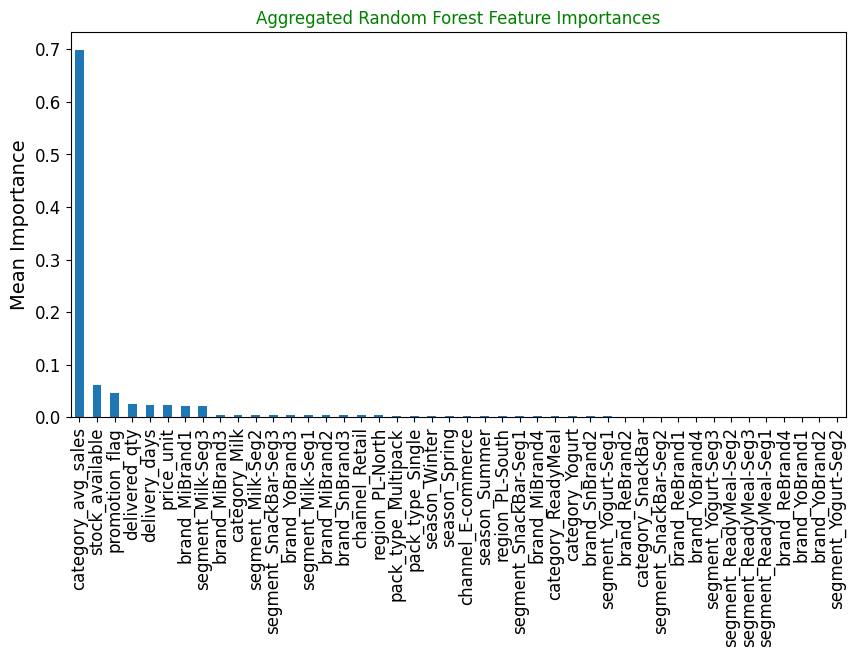

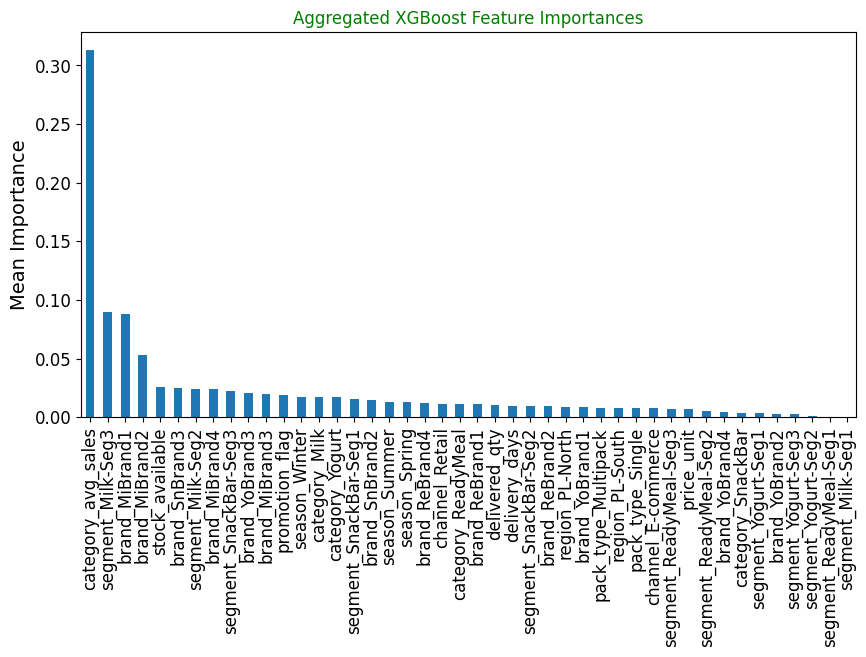


Best Model: RandomForest (MAE=0.101, R2=0.621)


In [56]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor
import numpy as np

# ---- TimeSeriesSplit instead of random split ----
tscv = TimeSeriesSplit(n_splits=5)

# Store metrics
results = {
    "LinearRegression": {"r2": [], "mae": []},
    "RandomForest": {"r2": [], "mae": []},
    "XGBoost": {"r2": [], "mae": []}
}

# Store feature importances
rf_importances = []
xgb_importances = []

for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # ---------------- Linear Regression ----------------
    pipe_lr = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LinearRegression())
    ])
    pipe_lr.fit(X_train, y_train)
    y_pred_lr = pipe_lr.predict(X_test)
    results["LinearRegression"]["r2"].append(r2_score(y_test, y_pred_lr))
    results["LinearRegression"]["mae"].append(mean_absolute_error(y_test, y_pred_lr))

    # ---------------- Random Forest ----------------
    pipe_rf = Pipeline([
        ('scaler', StandardScaler()),  # not really needed for RF
        ('rf', RandomForestRegressor(n_estimators=200, random_state=42))
    ])
    pipe_rf.fit(X_train, y_train)
    y_pred_rf = pipe_rf.predict(X_test)
    results["RandomForest"]["r2"].append(r2_score(y_test, y_pred_rf))
    results["RandomForest"]["mae"].append(mean_absolute_error(y_test, y_pred_rf))

    rf_importances.append(pipe_rf.named_steps['rf'].feature_importances_)

    # ---------------- XGBoost ----------------
    pipe_xgb = Pipeline([
        ('scaler', StandardScaler()),
        ('xgb', XGBRegressor(n_estimators=200, learning_rate=0.1,
                             max_depth=5, random_state=42, n_jobs=-1))
    ])
    pipe_xgb.fit(X_train, y_train)
    y_pred_xgb = pipe_xgb.predict(X_test)
    results["XGBoost"]["r2"].append(r2_score(y_test, y_pred_xgb))
    results["XGBoost"]["mae"].append(mean_absolute_error(y_test, y_pred_xgb))

    xgb_importances.append(pipe_xgb.named_steps['xgb'].feature_importances_)


# ================= Aggregate Results =================
print("\n===== Average Performance Across Folds =====")
summary = {}
for model in results:
    avg_r2 = np.mean(results[model]["r2"])
    avg_mae = np.mean(results[model]["mae"])
    summary[model] = {"R2": avg_r2, "MAE": avg_mae}
    print(f"{model}: R2={avg_r2:.3f}, MAE={avg_mae:.3f}")

# ================= Aggregate Feature Importances =================
# Random Forest
rf_importances_mean = np.mean(rf_importances, axis=0)
feat_imp_rf = pd.Series(rf_importances_mean, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
feat_imp_rf.plot(kind='bar')
plt.title("Aggregated Random Forest Feature Importances")
plt.ylabel("Mean Importance")
plt.show()

# XGBoost
xgb_importances_mean = np.mean(xgb_importances, axis=0)
feat_imp_xgb = pd.Series(xgb_importances_mean, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
feat_imp_xgb.plot(kind='bar')
plt.title("Aggregated XGBoost Feature Importances")
plt.ylabel("Mean Importance")
plt.show()

# ================= Select Best Model =================
best_model = min(summary.items(), key=lambda x: x[1]["MAE"])
print(f"\nBest Model: {best_model[0]} (MAE={best_model[1]['MAE']:.3f}, R2={best_model[1]['R2']:.3f})")


## Time Series Forecasting

Time series is a sequence of observations recorded at regular time intervals.

Depending on the frequency of observations, a time series may typically be hourly, daily, weekly, monthly, quarterly and annual. Sometimes, you might have seconds and minute-wise time series as well, like, number of clicks and user visits every minute etc.

Forecasting is the step where you want to predict the future values the series is going to take. Forecasting a time series (like demand and sales) is often of tremendous commercial value.

**Time Series Components:**

A useful abstraction for selecting forecasting methods is to break a time series down into systematic and unsystematic components. A given time series is thought to consist of three systematic components including level, trend, seasonality, and one non-systematic component called noise.

A series is thought to be an aggregate or combination of these four components. All series have a level and noise. The trend and seasonality components are optional.

It is helpful to think of the components as combining either additively or multiplicatively.

We will focus on a particular type of forecasting method called ARIMA modeling.

### ARIMA

ARIMA, short for 'Auto Regressive Integrated Moving Average' is a forecasting algorithm that 'explains' a given time series based on its own past values, that is, its own lags and the lagged forecast errors, so that equation can be used to forecast future values.

Any 'non-seasonal' time series that exhibits patterns and is not a random white noise can be modeled with ARIMA models.

An ARIMA model is characterized by 3 terms: p, d, q:

* p is the order of the AR term

* d is the number of differencing required to make the time series stationary

* q is the order of the MA term

The first step to build an ARIMA model is to **make the time series stationary**. Why?

Because, term 'Auto Regressive' in ARIMA means it is a linear regression model that uses its own lags as predictors. Linear regression models, as you know, work best when the predictors are not correlated and are independent of each other.

How to make a series stationary?

The most common approach is to difference it. That is, subtract the previous value from the current value. Sometimes, depending on the complexity of the series, more than one differencing may be needed.

**d** is the minimum number of differencing needed to make the series stationary. And if the time series is already stationary, then d = 0.

A pure **Auto Regressive (AR only) model** is one where Yt depends only on its own lags. And, **p** is the order of the 'Auto Regressive' (AR) term. It refers to the number of lags of Y to be used as predictors.

A pure **Moving Average (MA only) model** is one where Yt depends only on the lagged forecast errors. And, **q** is the order of the 'Moving Average' (MA) term. It refers to the number of lagged forecast errors that should go into the ARIMA Model.

**ARIMA model in words:**

Predicted Yt = Constant + Linear combination of Lags of Y (upto p lags) + Linear Combination of Lagged forecast errors (upto q lags)

##### Choose parameters for ARIMA

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [100]:
daily_df = pd.read_csv('../input/FMCG_2022_2024.csv')
daily_df['date'] = pd.to_datetime(daily_df['date'])
daily_df['year']= daily_df['date'].dt.year
daily_df = daily_df[daily_df['date']!=2025]
daily_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190757 entries, 0 to 190756
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   date             190757 non-null  datetime64[ns]
 1   sku              190757 non-null  object        
 2   brand            190757 non-null  object        
 3   segment          190757 non-null  object        
 4   category         190757 non-null  object        
 5   channel          190757 non-null  object        
 6   region           190757 non-null  object        
 7   pack_type        190757 non-null  object        
 8   price_unit       190757 non-null  float64       
 9   promotion_flag   190757 non-null  int64         
 10  delivery_days    190757 non-null  int64         
 11  stock_available  190757 non-null  int64         
 12  delivered_qty    190757 non-null  int64         
 13  units_sold       190757 non-null  int64         
 14  year             190

In [101]:

# Aggregate to weekly level per SKU (include 'category', 'segment', 'brand' explicitly)
df = df_daily.set_index('date').groupby(['sku', pd.Grouper(freq='W')]).agg({
    'units_sold': 'mean',  # Target: avg_weekly_sales
    'price_unit': 'mean',
    'promotion_flag': 'mean',
    'delivery_days': 'mean',
    'stock_available': 'mean',
    'delivered_qty': 'sum',
    'brand': 'first',
    'segment': 'first',
    'category': 'first',  # Ensure this is included
    'channel': lambda x: x.mode()[0] if not x.empty else np.nan,
    'region': lambda x: x.mode()[0] if not x.empty else np.nan,
    'pack_type': lambda x: x.mode()[0] if not x.empty else np.nan
}).reset_index()

df.rename(columns= {"units_sold": "avg_weekly_sales"}, inplace =True)

df.head()

,sku,date,avg_weekly_sales,price_unit,promotion_flag,delivery_days,stock_available,delivered_qty,brand,segment,category,channel,region,pack_type
0,JU-021,2022-07-17,20.759259,5.211852,0.074074,3.425926,158.074074,9532,JuBrand3,Juice-Seg3,Juice,Discount,PL-Central,Carton
1,JU-021,2022-07-24,23.692308,5.065962,0.153846,3.250000,168.019231,9666,JuBrand3,Juice-Seg3,Juice,Retail,PL-North,Carton
2,JU-021,2022-07-31,19.241379,5.186379,0.103448,2.879310,149.706897,10350,JuBrand3,Juice-Seg3,Juice,Discount,PL-North,Carton
3,JU-021,2022-08-07,17.867925,5.175660,0.132075,3.283019,151.622642,9415,JuBrand3,Juice-Seg3,Juice,E-commerce,PL-North,Carton
4,JU-021,2022-08-14,19.547170,5.171698,0.150943,3.075472,152.943396,9322,JuBrand3,Juice-Seg3,Juice,Discount,PL-North,Carton


In [102]:
# df.set_index('date', inplace=True)  # Set date as index
# df.head()


In [103]:
df.set_index('date', inplace=True)  # Set date as index
df.head()
df = df[['avg_weekly_sales']]  # Select only "AveragePrice" column
df = df.resample('W').mean() # Get weekly mean values for Average Price

In [104]:
df.head(10)

,avg_weekly_sales
date,
2022-01-23,12.677866
2022-01-30,12.613636
2022-02-06,14.536011
2022-02-13,13.287037
2022-02-20,13.018687
2022-02-27,12.623936
2022-03-06,16.746783
2022-03-13,16.982224
2022-03-20,18.546734


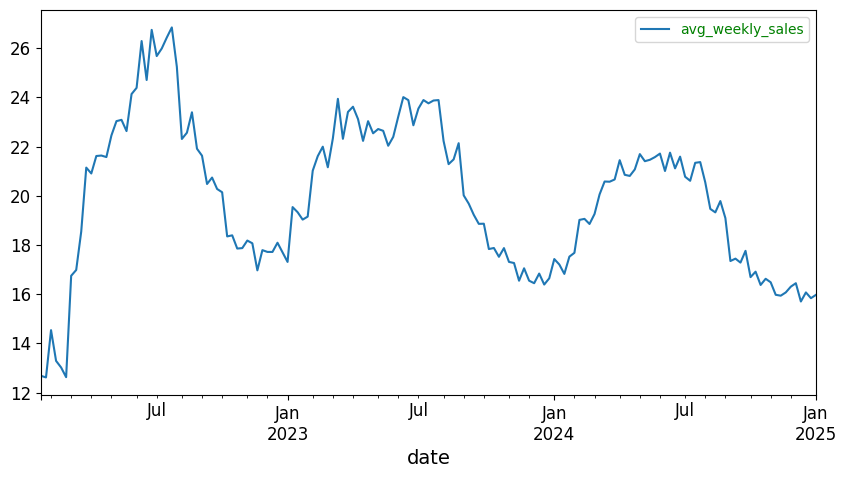

In [105]:
plt.rcParams['figure.figsize'] = [10, 5]
df.plot()
# Save the plot in "images" folder
plt.savefig("/Users/basazinbelhu/TimeSeries_Analysis_Prediction/images/rcparams.png", bbox_inches="tight")
plt.show()

As we can see from the plot, sales experienced a sharp rise in 2022 and reached a similar peak in 2023/24.  It wasn’t until the middle of 2022 that there were "large" swings in sales that were duplicated again in 2023/2024. 

**Let's look at the components of our time series:**

We will use additive model, which suggests that the components are added together as follows:

> Yt = Level + Trend + Seasonality + Noise

An additive model is linear where changes over time are consistently made by the same amount.

In [106]:
from statsmodels.tsa.seasonal import seasonal_decompose

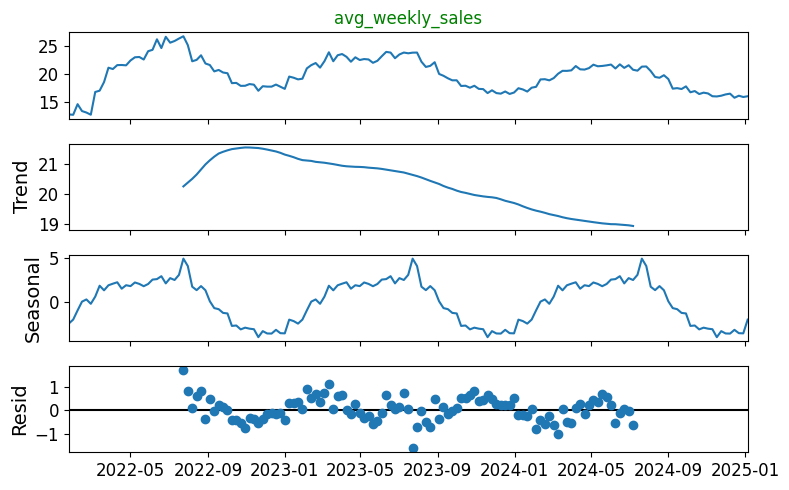

In [107]:
# Set figure size
plt.rcParams['figure.figsize'] = [8, 5]

# Decompose the series
a = seasonal_decompose(df["avg_weekly_sales"], model="add")

# Plot and save
fig = a.plot()
plt.ioff()

# Save the plot in "images" folder
plt.savefig("/Users/basazinbelhu/TimeSeries_Analysis_Prediction/images/seasonal_decompose.png", bbox_inches="tight")

plt.show()


##### Find order of differencing i.e. 'd':

The purpose of differencing it to make the time series stationary.

But we need to be careful to not over-difference the series. Because, an over differenced series may still be stationary, which in turn will affect the model parameters.

First, we will check stationarity using Augmented Dickey Fuller Test. The null hypothesis of the ADF test is that the time series is non-stationary. So, if the p-value of the test is less than the significance level (0.05) then you reject the null hypothesis and infer that the time series is indeed stationary.

In [108]:
from statsmodels.tsa.stattools import adfuller

In [109]:
result = adfuller(df.avg_weekly_sales.dropna())
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

ADF Statistic: -4.370676
p-value: 0.000334


Since p-value is greater than the significance level, let’s difference the series and see how the autocorrelation plot looks like.

In [111]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

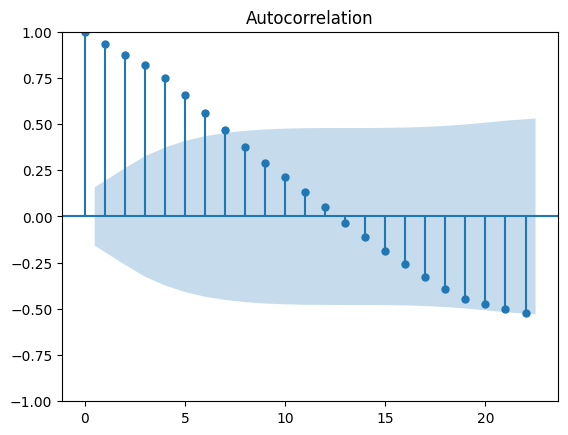

In [112]:
plt.style.use('default')
plot_acf(df.avg_weekly_sales)
# Save the plot in "images" folder
plt.savefig("/Users/basazinbelhu/TimeSeries_Analysis_Prediction/images/autocorrelation.png", bbox_inches="tight")
plt.show();

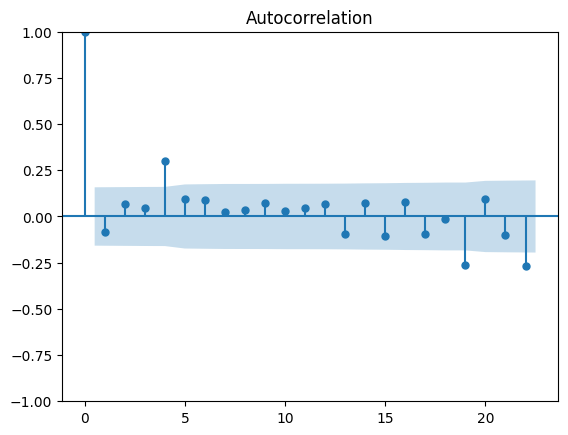

In [113]:
# 1st order differencing
plot_acf(df.avg_weekly_sales.diff().dropna());
plt.show()

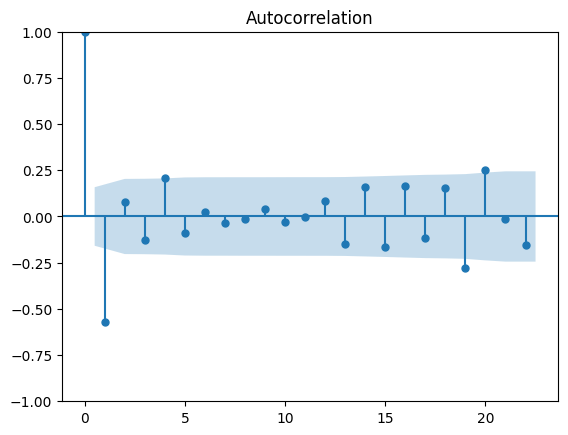

In [114]:
# 2nd order differencing
plot_acf(df.avg_weekly_sales.diff().diff().dropna());
plt.show()

From above plots we can see that the time series reaches stationarity with one order of differencing.

We can also use 'ndiffs' to estimate 'd'. It performs a test of stationarity for different levels of d to estimate the number of differences required to make a given time series stationary. It will select the maximum value of d for which the time series is judged stationary by the statistical test.

In [115]:
import numpy as np
from statsmodels.tsa.stattools import adfuller

def custom_ndiffs(series, test='adf', max_d=5, alpha=0.05):
    """Estimate number of differences for stationarity using ADF test.
    - series: pandas Series or numpy array.
    - test: 'adf' (only supported; extend for 'kpss' if needed).
    - max_d: Max differences to prevent loop.
    - alpha: Significance level.
    Returns: int (d value).
    """
    d = 0
    current_series = np.asarray(series)
    while d < max_d:
        result = adfuller(current_series)
        p_value = result[1]
        if p_value < alpha:
            return d
        current_series = np.diff(current_series)
        d += 1
    return d


In [116]:
# Example: Replace 'your_series' with e.g., df_weekly['avg_weekly_sales']
d = custom_ndiffs(df.avg_weekly_sales)
print(f"Estimated d: {d}")

Estimated d: 0


##### Find order of AR term i.e. 'p':

The next step is to identify if the model needs any AR terms. You can find out the required number of AR terms by inspecting the Partial Autocorrelation (PACF) plot. Partial autocorrelation can be imagined as the correlation between the series and its lag, after excluding the contributions from the intermediate lags.

Let's see how partial autocorrelation plots look like.

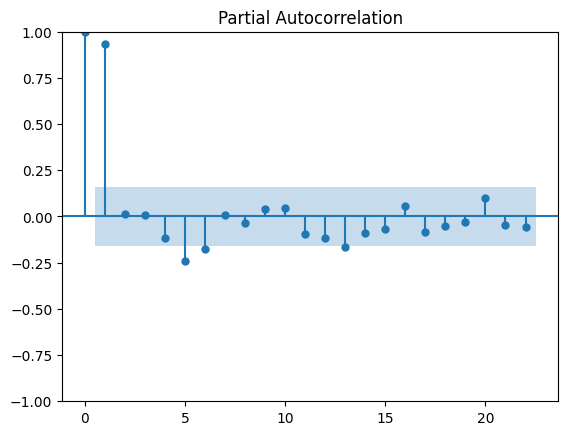

In [117]:
plot_pacf(df.avg_weekly_sales)
# Save the plot in "images" folder
plt.savefig("/Users/basazinbelhu/TimeSeries_Analysis_Prediction/images/partial_autocorrelation.png", bbox_inches="tight")
plt.show();

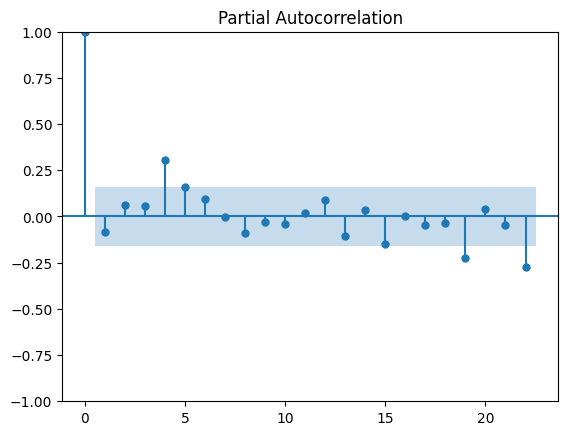

In [118]:
# 1st order differencing
plot_pacf(df.avg_weekly_sales.diff().dropna());
plt.show()

We can observe that the PACF without any lag is quite significant and well within the significance limit (blue region).So we will choose p as 0.

##### Find order of MA term i.e. 'q':

Just like how we looked at the PACF plot for the number of AR terms, you can look at the ACF plot for the number of MA terms. An MA term is technically, the error of the lagged forecast.

The ACF tells how many MA terms are required to remove any autocorrelation in the stationarized series.

Let’s see the autocorrelation plot of the differenced series.

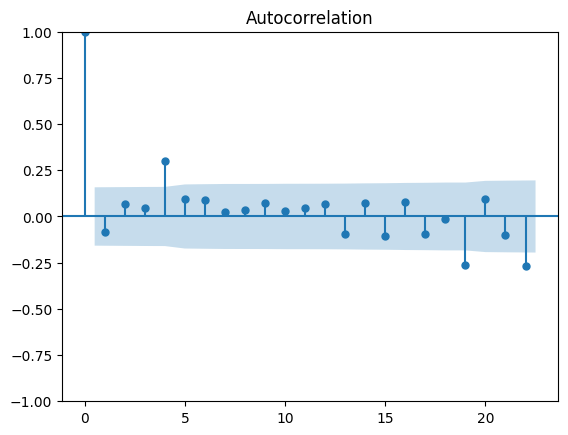

In [119]:
plot_acf(df.avg_weekly_sales.diff().dropna());
plt.show()

The lags are well within the significance limit. So, we wil choose q as 0.

### Build ARIMA Model

In [120]:
df = df.dropna()

In [121]:
from statsmodels.tsa.arima_model import ARIMA
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [122]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import numpy as np

def evaluate_arima_model(X, arima_order):
    X = np.asarray(X)
    if len(X) < 10 or np.any(np.isnan(X)):
        return float("inf")
    train_size = int(len(X) * 0.66)
    train, test = X[:train_size], X[train_size:]
    history = list(train)
    predictions = list()
    for t in range(len(test)):
        try:
            model = ARIMA(history, order=arima_order)
            model_fit = model.fit(disp=0)  # No 'method'; default works
            yhat = model_fit.forecast()[0]
            predictions.append(yhat)
            history.append(test[t])
        except:
            return float("inf")
    return mean_squared_error(test, predictions)

def evaluate_models(dataset, p_values, d_values, q_values):
    dataset = np.asarray(dataset).astype('float32')
    best_score, best_cfg = float("inf"), None
    for p in p_values:
        for d in d_values:
            for q in q_values:
                order = (p, d, q)
                try:
                    mse = evaluate_arima_model(dataset, order)
                    if mse < best_score:
                        best_score, best_cfg = mse, order
                    print('ARIMA%s MSE=%.3f' % (order, mse))
                except Exception as e:
                    print('ARIMA%s failed: %s' % (order, str(e)))
                    continue
    print('Best ARIMA%s MSE=%.3f' % (best_cfg, best_score))
    return best_cfg

In [123]:
# evaluate parameters
p_values = range(1, 2)
d_values = range(0, 4)
q_values = range(0, 2)

best_order = evaluate_models(df.avg_weekly_sales, p_values, d_values, q_values)

ARIMA(1, 0, 0) MSE=inf
ARIMA(1, 0, 1) MSE=inf
ARIMA(1, 1, 0) MSE=inf
ARIMA(1, 1, 1) MSE=inf
ARIMA(1, 2, 0) MSE=inf
ARIMA(1, 2, 1) MSE=inf
ARIMA(1, 3, 0) MSE=inf
ARIMA(1, 3, 1) MSE=inf
Best ARIMANone MSE=inf


In [124]:
df.head()

,avg_weekly_sales
date,
2022-01-23,12.677866
2022-01-30,12.613636
2022-02-06,14.536011
2022-02-13,13.287037
2022-02-20,13.018687


In [125]:
best_order = (1, 1, 1)   # p, d, q


In [126]:
from statsmodels.tsa.arima.model import ARIMA  # Updated import

# Instantiate the ARIMA model (assuming best_order is defined, e.g., (p, d, q))
# model = ARIMA(df['avg_weekly_sales'], order=best_order)
model = ARIMA(df['avg_weekly_sales'], order=best_order)
results_ARIMA = model.fit()
print(results_ARIMA.summary())

forecast = results_ARIMA.forecast(steps=4)
print(forecast)

                               SARIMAX Results                                
Dep. Variable:       avg_weekly_sales   No. Observations:                  155
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -198.645
Date:                Thu, 18 Sep 2025   AIC                            403.289
Time:                        22:12:34   BIC                            412.400
Sample:                    01-23-2022   HQIC                           406.990
                         - 01-05-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9783      0.035    -27.636      0.000      -1.048      -0.909
ma.L1          0.9372      0.064     14.565      0.000       0.811       1.063
sigma2         0.7711      0.053     14.487      0.0

In [127]:
results_ARIMA.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:       avg_weekly_sales   No. Observations:                  155
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -198.645
Date:                Thu, 18 Sep 2025   AIC                            403.289
Time:                        22:12:36   BIC                            412.400
Sample:                    01-23-2022   HQIC                           406.990
                         - 01-05-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9783      0.035    -27.636      0.000      -1.048      -0.909
ma.L1          0.9372      0.064     14.565      0.000       0.811       1.063
sigma2         0.7711      0.053     14.487      0.000       0.667       0.875
===================================================================================
Ljung-Box (L1) (Q):                   0.05   Jarque-Bera (JB):                83.29
Prob(Q):                              0.83   Prob(JB):                         0.00
Heteroskedasticity (H):               0.24   Skew:                             0.45
Prob(H) (two-sided):                  0.00   Kurtosis:                         6.49
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Let’s plot the residuals to ensure there are no patterns (that is, look for constant mean and variance).

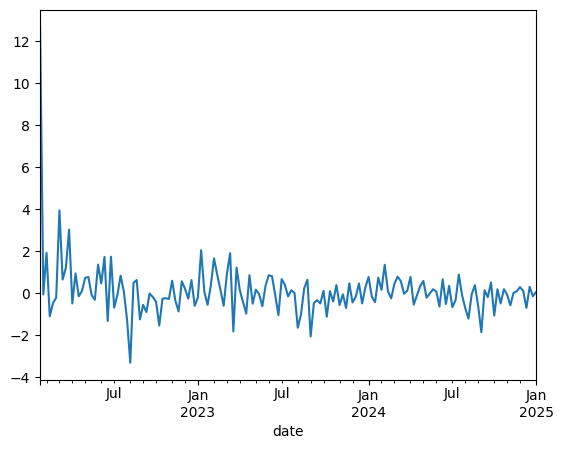

In [128]:
# line plot of residuals
residuals = results_ARIMA.resid
residuals.plot()
plt.show()

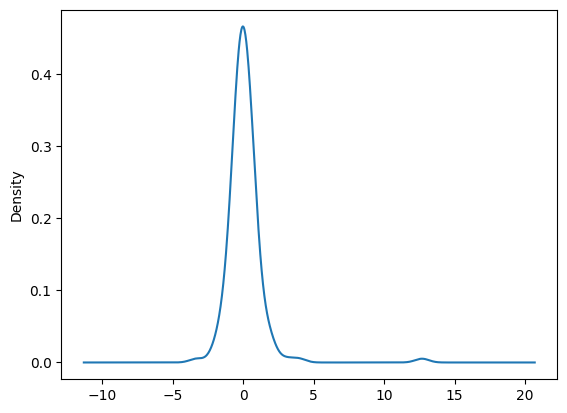

In [129]:
# density plot of residuals
residuals.plot(kind='kde')
plt.show()

The residual errors seem fine with near zero mean and uniform variance.

In [130]:
print(residuals.describe())

count    155.000000
mean       0.103696
std        1.344624
min       -3.314548
25%       -0.487064
50%       -0.018098
75%        0.476153
max       12.677866
dtype: float64


### Forecasting and Evaluation

Let's plot the actuals against the fitted values using plot_predict(). When you set "dynamic" as 'False', the in-sample lagged values are used for prediction.

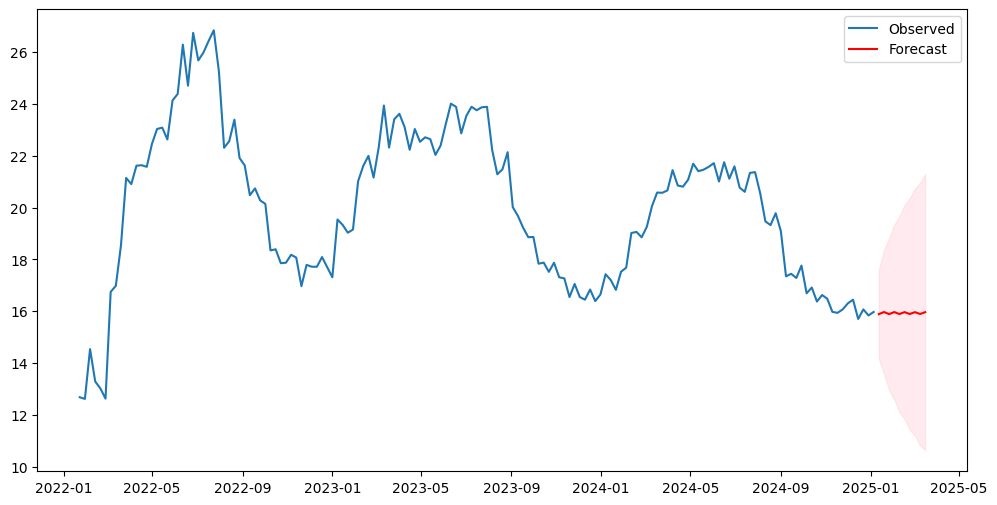

In [131]:
import matplotlib.pyplot as plt

# Forecast 10 steps ahead (adjust as needed)
forecast_obj = results_ARIMA.get_forecast(steps=10)
forecast_mean = forecast_obj.predicted_mean
forecast_ci = forecast_obj.conf_int()

# Plot observed values
plt.figure(figsize=(12, 6))
plt.plot(df['avg_weekly_sales'], label="Observed")

# Plot forecast
plt.plot(forecast_mean.index, forecast_mean, label="Forecast", color="red")

# Confidence intervals
plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    color="pink", alpha=0.3
)

plt.legend()
plt.show()


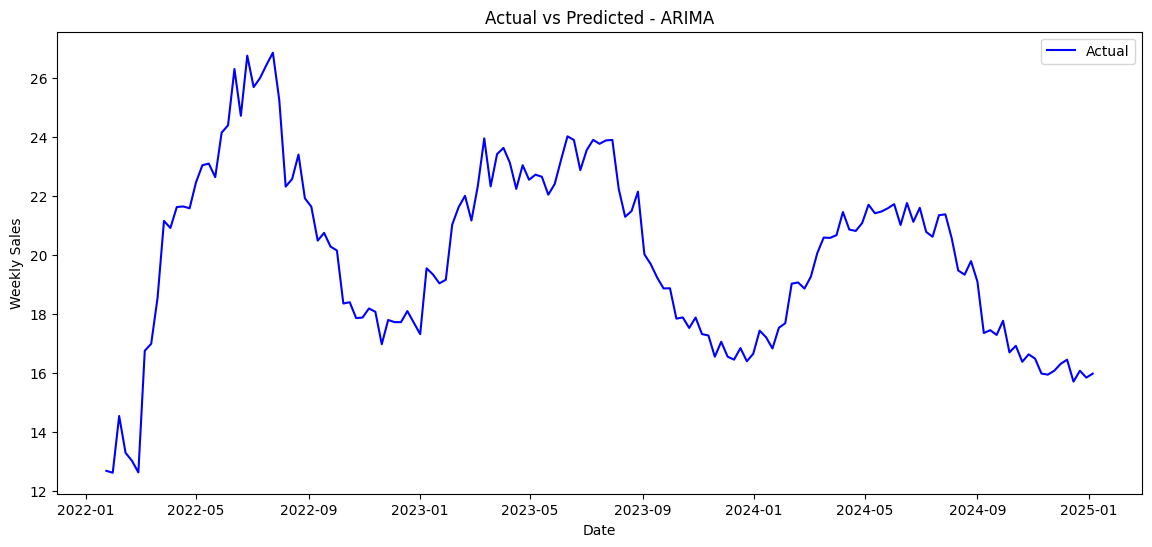

In [132]:
# In-sample prediction for the entire available range
pred = results_ARIMA.get_prediction(start=df.index[0], end=df.index[-1], dynamic=False)
pred_mean = pred.predicted_mean

# Align indices just in case
pred_mean = pred_mean.reindex(df.index)

# Plot actual vs predicted
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['avg_weekly_sales'], label="Actual", color="blue")
# plt.plot(df.index, pred_mean, label="Predicted", color="red", linestyle="--")

plt.title("Actual vs Predicted - ARIMA")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.show()


In [133]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Get in-sample predictions (dynamic=False means one-step ahead forecast)
pred = results_ARIMA.get_prediction(start=0, end=len(df)-1, dynamic=False)
pred_mean = pred.predicted_mean

# Create dataframe of actual vs predicted
predicted_df = pd.DataFrame({
    'Averagesales': df['avg_weekly_sales'],
    'Predictedsales': pred_mean
})

# Calculate metrics
mape = np.mean(np.abs(predicted_df['Predictedsales'] - predicted_df['Averagesales']) /
               np.abs(predicted_df['Averagesales']))
mae = mean_absolute_error(predicted_df['Averagesales'], predicted_df['Predictedsales'])
mse = mean_squared_error(predicted_df['Averagesales'], predicted_df['Predictedsales'])

print("\tMean Absolute Percentage Error:", mape)
print("\tMean Absolute Error:", mae)
print("\tMean Squared Error:", mse)


	Mean Absolute Percentage Error: 0.03754607342615537
	Mean Absolute Error: 0.7009196755112083
	Mean Squared Error: 1.8071027333172343


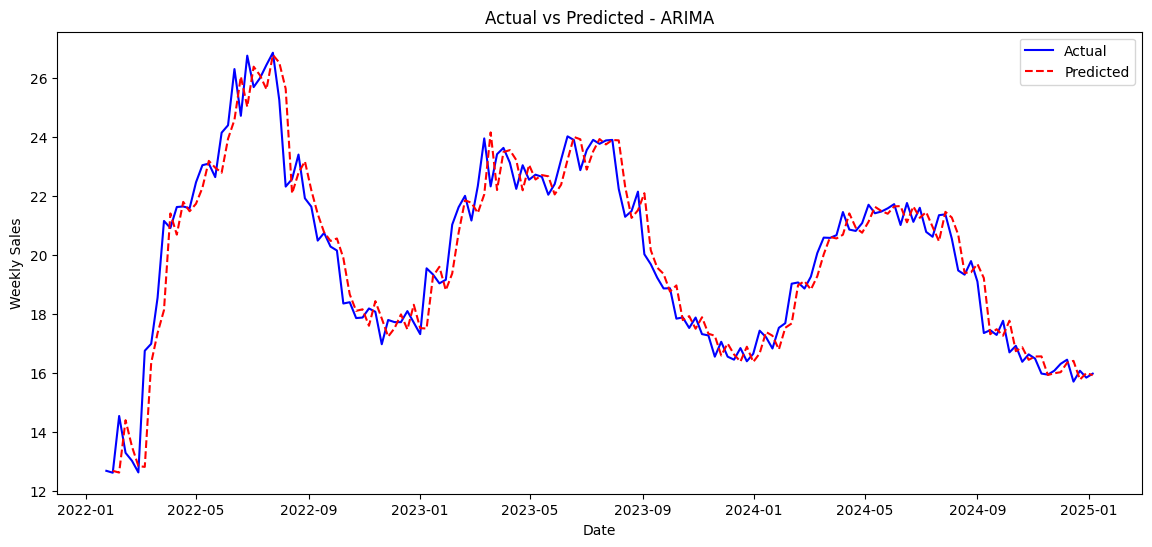

In [134]:
# In-sample prediction for the entire available range
p, d, q = best_order
pred = results_ARIMA.get_prediction(start=d, end=len(df)-1, dynamic=False)
pred_mean = pred.predicted_mean

# Align indices just in case
pred_mean = pred_mean.reindex(df.index)

# Plot actual vs predicted
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['avg_weekly_sales'], label="Actual", color="blue")
plt.plot(df.index, pred_mean, label="Predicted", color="red", linestyle="--")

plt.title("Actual vs Predicted - ARIMA")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
# Save the plot in "images" folder
plt.savefig("/Users/basazinbelhu/TimeSeries_Analysis_Prediction/images/arima_predicted_actual.png", bbox_inches="tight")
plt.show()


The problem with plain ARIMA model is it does not support seasonality.

### SARIMA

If your time series has defined seasonality, then, go for SARIMA which uses seasonal differencing.

Seasonal differencing is similar to regular differencing, but, instead of subtracting consecutive terms, you subtract the value from previous season.

So, the model will be represented as SARIMA(p,d,q)x(P,D,Q), where, P, D and Q are SAR, order of seasonal differencing and SMA terms respectively and 'x' is the frequency of the time series.

If your model has well defined seasonal patterns, then enforce D=1 for a given frequency 'x'.

In [135]:
import statsmodels.api as sm

In [138]:
mod = sm.tsa.statespace.SARIMAX(df['avg_weekly_sales'],
                                order=(1, 0, 0),
                                seasonal_order=(1, 1, 1, 12),
                                enforce_stationarity=False,
                                enforce_invertibility=False)
results = mod.fit()

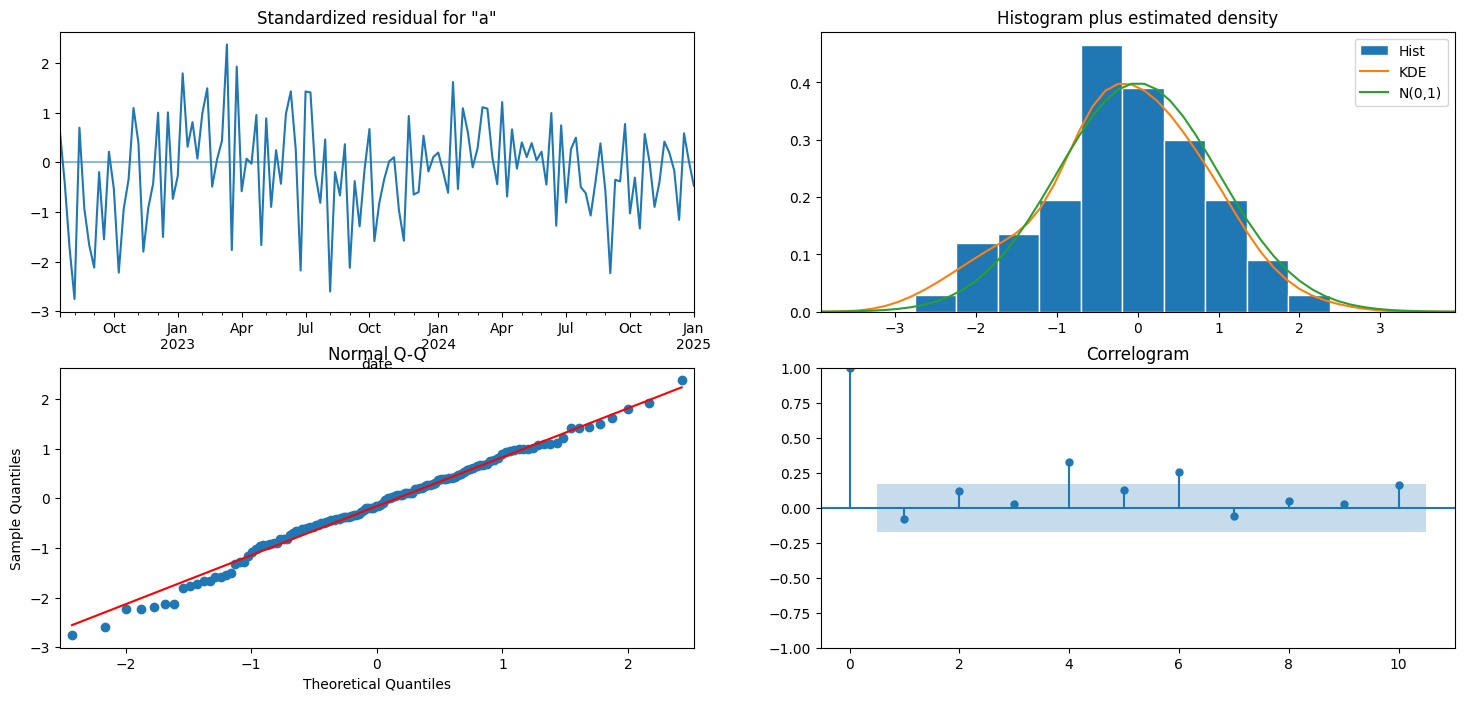

In [139]:
results.plot_diagnostics(figsize=(18, 8))
plt.ioff()
# Save the plot in "images" folder
plt.savefig("/Users/basazinbelhu/TimeSeries_Analysis_Prediction/images/sarima_diagnostics.png", bbox_inches="tight")
plt.show()

* The SARIMA model fits the weekly FMCG sales data well.
* Residuals are uncorrelated, centered around zero, and roughly normal.
* Slight fat tails suggest occasional extreme sales weeks may not be fully explained (e.g., promotions, holidays, supply chain shocks).

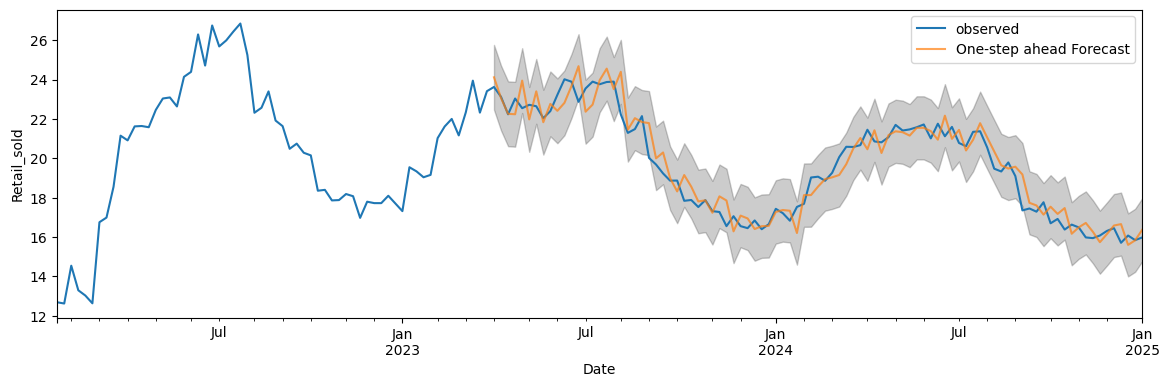

In [140]:
pred = results.get_prediction(start=pd.to_datetime('2023-04-02'), dynamic=False)
pred_ci = pred.conf_int()
ax = df['avg_weekly_sales'].plot(label='observed')
pred.predicted_mean.plot(ax=ax, label='One-step ahead Forecast', alpha=.7, figsize=(14, 4))
ax.fill_between(pred_ci.index,
                pred_ci.iloc[:, 0],
                pred_ci.iloc[:, 1], color='k', alpha=.2)
ax.set_xlabel('Date')
ax.set_ylabel('Retail_sold')
plt.legend()
plt.savefig("/Users/basazinbelhu/TimeSeries_Analysis_Prediction/images/sarima_predition.png", bbox_inches="tight")

plt.show()

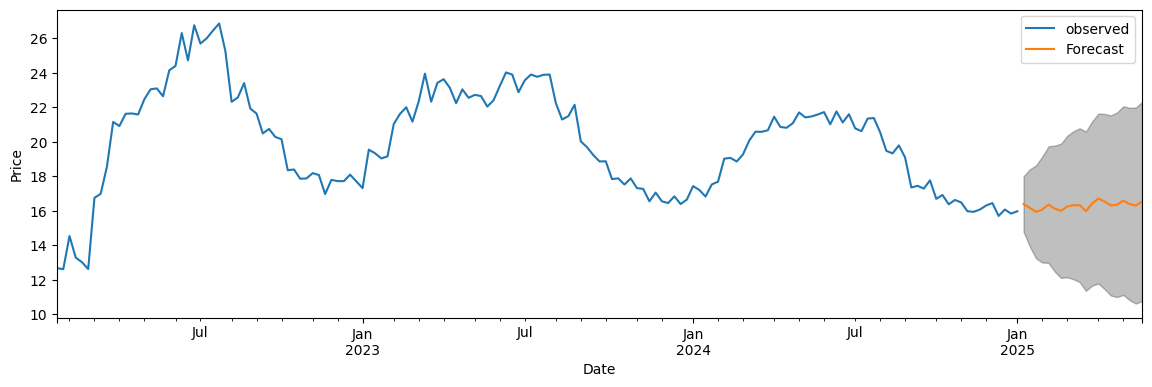

In [141]:
pred_uc = results.get_forecast(steps=20)
pred_ci = pred_uc.conf_int()
ax = df['avg_weekly_sales'].plot(label='observed', figsize=(14, 4))
pred_uc.predicted_mean.plot(ax=ax, label='Forecast')
ax.fill_between(pred_ci.index,
                pred_ci.iloc[:, 0],
                pred_ci.iloc[:, 1], color='k', alpha=.25)
ax.set_xlabel('Date')
ax.set_ylabel('Price')
plt.legend()
plt.show()

## Forecasting using Facebook Prophet

Install Prophet using either command prompt or Anaconda prompt using pip:

**pip install fbprophet**

We need to install plotly for plotting the data for prophet

**pip install plotly**

Prophet is an open-source library designed for making forecasts for univariate (one variable) time series datasets. It is easy to use and designed to automatically find a good set of hyperparameters for the model in an effort to make skillful forecasts for data with trends and seasonal structure by default. It was initially developed for the purpose of creating high quality business forecasts. It helps businesses understand and possibly predict the market. This library tries to address the following difficulties common to many business time series:

* Seasonal effects caused by human behavior: weekly, monthly and yearly cycles, dips and peaks on public holidays.
* Changes in trend due to new products and market events.
* Outliers.

It is based on a decomposable additive model where non-linear trends are fit with seasonality, it also takes into account the effects of holidays. Before we head right into coding, let’s learn certain terms that are required to understand this.

**Trend:**
The trend shows the tendency of the data to increase or decrease over a long period of time and it filters out the seasonal variations.

**Seasonality:**
Seasonality is the variations that occur over a short period of time and is not prominent enough to be called a “trend”.

**Understanding the Prophet Model:**
The general idea of the model is similar to a generalized additive model. The “Prophet Equation” fits, as mentioned above, trend, seasonality and holidays. This is given by,

    y(t) = g(t)+s(t)+h(t)+e(t)
    
where,

* g(t) refers to trend (changes over a long period of time)
* s(t) refers to seasonality (periodic or short term changes)
* h(t) refers to effects of holidays to the forecast
* e(t) refers to the unconditional changes that is specific to a business or a person or a circumstance. It is also called the error term.
* y(t) is the forecast.

Input to Prophet is a dataframe which must have a specific format. The first column must have the name 'ds' while the second column must have the name 'y'.

ds is ***datestamp column*** and should be as per pandas datetime format, YYYY-MM-DD or YYYY-MM-DD HH:MM:SS for a timestamp.

y is the ***numeric column we want to predict or forecast***.

This means we change the column names in the dataset. It also requires that the first column be converted to date-time objects, if they are not already.

In [142]:
import numpy as np
import pandas as pd

from prophet import Prophet
from prophet.plot import plot_plotly
from prophet.plot import add_changepoints_to_plot

import matplotlib.pyplot as plt

In [143]:
daily_df = pd.read_csv('../input/FMCG_2022_2024.csv')
daily_df['date'] = pd.to_datetime(daily_df['date'])
daily_df['year']= daily_df['date'].dt.year
daily_df = daily_df[daily_df['date']!=2025]
daily_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190757 entries, 0 to 190756
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   date             190757 non-null  datetime64[ns]
 1   sku              190757 non-null  object        
 2   brand            190757 non-null  object        
 3   segment          190757 non-null  object        
 4   category         190757 non-null  object        
 5   channel          190757 non-null  object        
 6   region           190757 non-null  object        
 7   pack_type        190757 non-null  object        
 8   price_unit       190757 non-null  float64       
 9   promotion_flag   190757 non-null  int64         
 10  delivery_days    190757 non-null  int64         
 11  stock_available  190757 non-null  int64         
 12  delivered_qty    190757 non-null  int64         
 13  units_sold       190757 non-null  int64         
 14  year             190

In [144]:

# Aggregate to weekly level per SKU (include 'category', 'segment', 'brand' explicitly)
df = df_daily.set_index('date').groupby(['sku', pd.Grouper(freq='W')]).agg({
    'units_sold': 'mean',  # Target: avg_weekly_sales
    'price_unit': 'mean',
    'promotion_flag': 'mean',
    'delivery_days': 'mean',
    'stock_available': 'mean',
    'delivered_qty': 'sum',
    'brand': 'first',
    'segment': 'first',
    'category': 'first',  # Ensure this is included
    'channel': lambda x: x.mode()[0] if not x.empty else np.nan,
    'region': lambda x: x.mode()[0] if not x.empty else np.nan,
    'pack_type': lambda x: x.mode()[0] if not x.empty else np.nan
}).reset_index()

df.rename(columns= {"units_sold": "avg_weekly_sales"}, inplace =True)

df.head()

,sku,date,avg_weekly_sales,price_unit,promotion_flag,delivery_days,stock_available,delivered_qty,brand,segment,category,channel,region,pack_type
0,JU-021,2022-07-17,20.759259,5.211852,0.074074,3.425926,158.074074,9532,JuBrand3,Juice-Seg3,Juice,Discount,PL-Central,Carton
1,JU-021,2022-07-24,23.692308,5.065962,0.153846,3.250000,168.019231,9666,JuBrand3,Juice-Seg3,Juice,Retail,PL-North,Carton
2,JU-021,2022-07-31,19.241379,5.186379,0.103448,2.879310,149.706897,10350,JuBrand3,Juice-Seg3,Juice,Discount,PL-North,Carton
3,JU-021,2022-08-07,17.867925,5.175660,0.132075,3.283019,151.622642,9415,JuBrand3,Juice-Seg3,Juice,E-commerce,PL-North,Carton
4,JU-021,2022-08-14,19.547170,5.171698,0.150943,3.075472,152.943396,9322,JuBrand3,Juice-Seg3,Juice,Discount,PL-North,Carton


In [145]:
df.set_index('date', inplace = True)

In [146]:
df2_week = df[["avg_weekly_sales"]].copy()
df2_week = df.groupby('date')[['avg_weekly_sales']].mean()
df2_week.reset_index(inplace=True)
df2_week.columns = ['ds','y']
df2_week.head()

,ds,y
0,2022-01-23,12.677866
1,2022-01-30,12.613636
2,2022-02-06,14.536011
3,2022-02-13,13.287037
4,2022-02-20,13.018687


In [147]:
df2_week.shape

(155, 2)

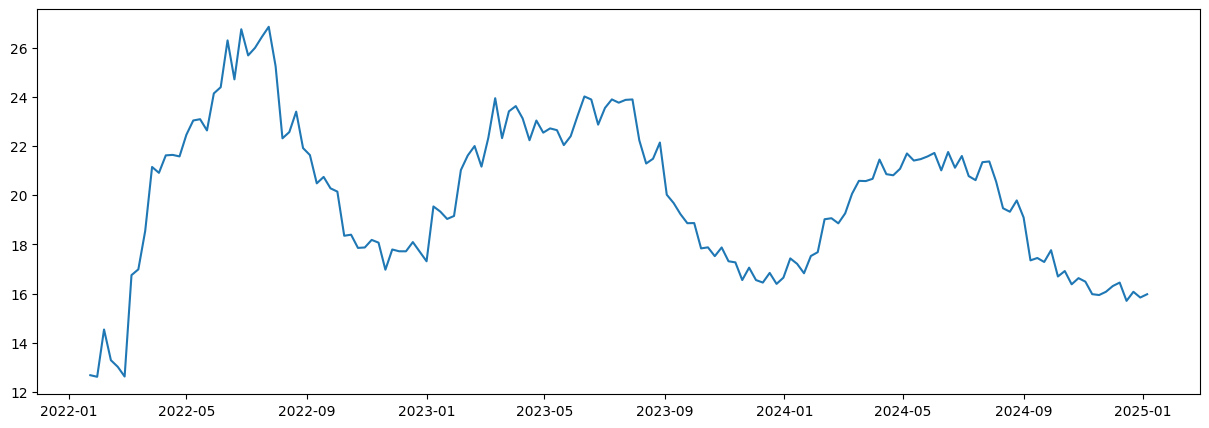

In [148]:
fig = plt.figure(figsize = (15,5))
plt.plot(df2_week.ds, df2_week.y)
plt.show()

In [149]:
# Resample from weekly to monthly
df2_month = df[["avg_weekly_sales"]].resample('MS').mean()
df2_month.head()

,avg_weekly_sales
date,
2022-01-01,12.645751
2022-02-01,13.366418
2022-03-01,18.462558
2022-04-01,21.478818
2022-05-01,23.096175


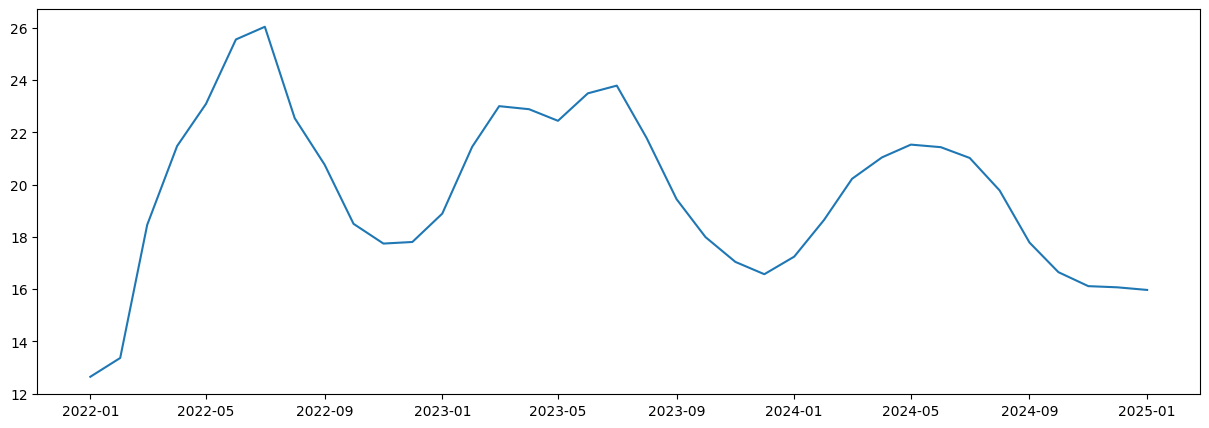

In [150]:
fig = plt.figure(figsize = (15,5))
plt.plot(df2_month.index, df2_month.avg_weekly_sales)
plt.show()

In [151]:
df2_month.reset_index(inplace=True)
df2_month.columns = ['ds','y']

### Fit Prophet Model

Prophet's API is very similar to the one you can find in sklearn. To use Prophet for forecasting, first, a Prophet() object is defined and configured, then it is fit on the dataset by calling the fit() function and passing the data, and, finally, make a forecast.

The Prophet() object takes arguments to configure the type of model you want, such as the type of growth, the type of seasonality, and more. By default, the model will work hard to figure out almost everything automatically.

The fit() function takes a DataFrame of time series data.

In [152]:
df2_week.shape

(155, 2)

In [153]:
# Split data 70-30
prediction_size = 40
train_dataset = df2_week[:-prediction_size]
test_dataset = df2_week[-prediction_size:]

Now we need to create a new Prophet object. Here we can pass the parameters of the model into the constructor. Intially, we will use the defaults. Then we train our model by invoking its fit method on our training dataset:

In [154]:
prophet_basic = Prophet()
prophet_basic.fit(train_dataset)

22:14:45 - cmdstanpy - INFO - Chain [1] start processing
22:14:46 - cmdstanpy - INFO - Chain [1] done processing


### Forecasting

A forecast is made by calling the predict() function and passing a DataFrame that contains one column named 'ds' and rows with date-times for all the intervals to be predicted.

Using the helper method Prophet.make_future_dataframe, we create a dataframe which will contain all dates from the history and also extend into the future for those 50 weeks that we left out before.

In [155]:
future= prophet_basic.make_future_dataframe(periods=prediction_size, freq='W')

In [156]:
forecast = prophet_basic.predict(future)

In [157]:
forecast.head(2)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2022-01-23,14.708414,11.637492,13.593144,14.708414,14.708414,-2.084823,-2.084823,-2.084823,-2.084823,-2.084823,-2.084823,0.0,0.0,0.0,12.623591
1,2022-01-30,15.042041,12.321724,14.212656,15.042041,15.042041,-1.742281,-1.742281,-1.742281,-1.742281,-1.742281,-1.742281,0.0,0.0,0.0,13.299760


The result of the predict() function is a DataFrame that contains many columns. Perhaps the most important columns are the forecast date time ('ds'), the forecasted value ('yhat'), and the lower and upper bounds on the predicted value ('yhat_lower' and 'yhat_upper') that provide uncertainty of the forecast.

In [158]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper', 'trend', 'trend_lower', 'trend_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper,trend,trend_lower,trend_upper
150,2024-12-08,14.733096,12.919721,16.605634,18.312466,16.857376,19.765358
151,2024-12-15,14.814326,12.941921,16.629479,18.281746,16.757695,19.785260
152,2024-12-22,14.868651,13.031173,16.777656,18.251027,16.639284,19.812839
153,2024-12-29,14.991712,13.018880,16.803845,18.220308,16.542271,19.843373
154,2025-01-05,15.245994,13.219494,17.238268,18.189588,16.423998,19.882883


### Forecast quality evaluation

In [159]:
# Create comparision dataframe
cmp_df = forecast.set_index('ds')[['yhat', 'yhat_lower', 'yhat_upper']].join(df2_week.set_index('ds'))
cmp_df.head()

,yhat,yhat_lower,yhat_upper,y
ds,,,,
2022-01-23,12.623591,11.637492,13.593144,12.677866
2022-01-30,13.299760,12.321724,14.212656,12.613636
2022-02-06,14.019796,13.032704,15.003624,14.536011
2022-02-13,14.687514,13.651624,15.641117,13.287037
2022-02-20,15.219234,14.244234,16.193895,13.018687


In [160]:
cmp_df['e'] = cmp_df['y'] - cmp_df['yhat']
cmp_df['p'] = 100 * cmp_df['e'] / cmp_df['y']

In [161]:
predicted_part = cmp_df[-prediction_size:]

MAPE is widely used as a measure of prediction accuracy because it expresses error as a percentage and thus can be used in model evaluations on different datasets.

In addition, when evaluating a forecasting algorithm, it may prove useful to calculate MAE (Mean Absolute Error) in order to have a picture of errors in absolute numbers.

In [162]:
# Mean Absolute Percentage Error
mape = np.mean(np.abs(predicted_part['p']))
print('MAPE:', mape)

MAPE: 4.627619526785497


In [163]:
# Mean Absolute Error
mae = np.mean(np.abs(predicted_part['e']))
print('MAE:', mae)

MAE: 0.8506686046725548


### Visualization

The Prophet library has its own built-in tools for visualization that enable us to quickly evaluate the result.

First, there is a method called Prophet.plot that will create a plot of the dataset and overlay the prediction with the upper and lower bounds for the forecast dates:

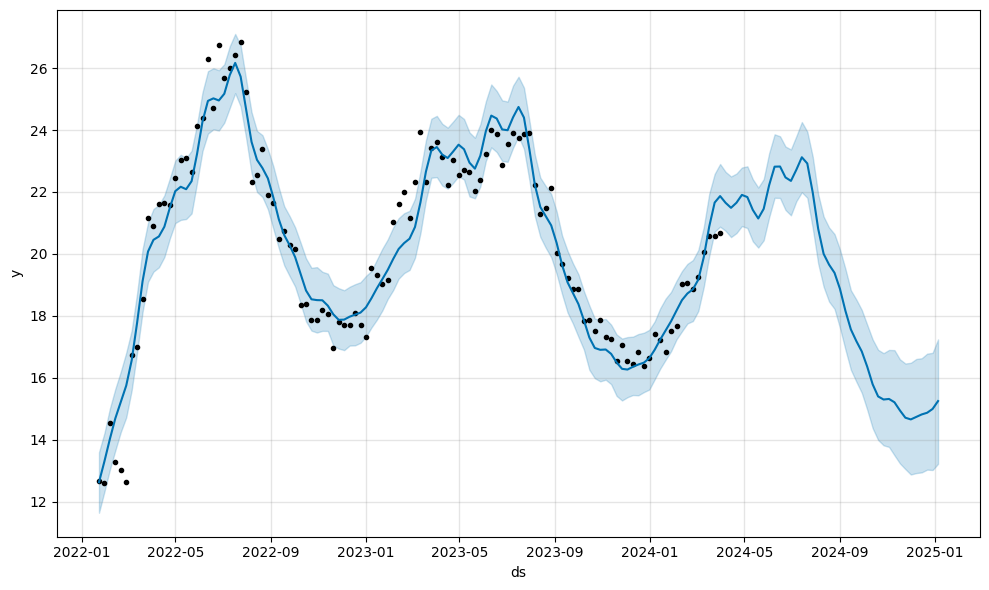

In [164]:
fig1 = prophet_basic.plot(forecast)
# Save the plot in "images" folder
plt.savefig("/Users/basazinbelhu/TimeSeries_Analysis_Prediction/images/prophet_forcast.png", bbox_inches="tight")
plt.show()

The second function Prophet.plot_components might be much more useful in our case. It allows us to observe different components of the model separately: trend, yearly and weekly seasonality. In addition, if you supply information about holidays and events to your model, they will also be shown in this plot.

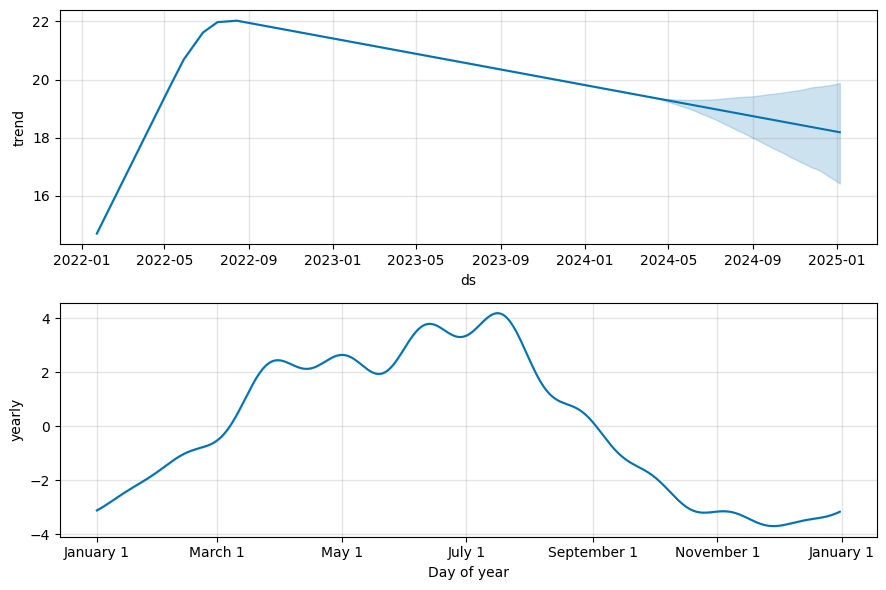

In [165]:
fig1 = prophet_basic.plot_components(forecast)
# Save the plot in "images" folder
plt.savefig("/Users/basazinbelhu/TimeSeries_Analysis_Prediction/images/prophet_forcast_component.png", bbox_inches="tight")
plt.show()

The above plots show the trends and seasonality(in a year) of the time series data. We can see there is first an increase and then a decrease trend, meaning the sales initially dipped and then increased over time. If we look at the seasonality graph, we can see that May to mid July have the highest sales at a given year.

### Adding ChangePoints to Prophet

Changepoints are the datetime points where the time series have abrupt changes in the trajectory.

By default, Prophet adds 25 changepoints into the initial 80% of the data-set. The number of changepoints can be set by using the n_changepoints parameter when initializing prophet (e.g., model=Prophet(n_changepoints=30)).

Let’s plot the vertical lines where the potential changepoints occurred

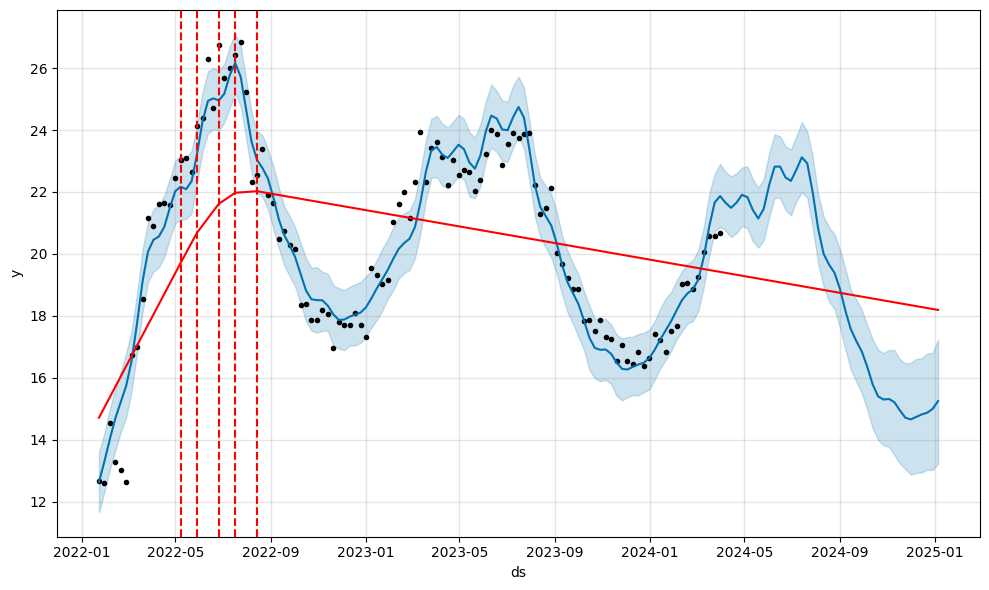

In [166]:
fig = prophet_basic.plot(forecast)
a = add_changepoints_to_plot(fig.gca(), prophet_basic, forecast)
# Save the plot in "images" folder
plt.savefig("/Users/basazinbelhu/TimeSeries_Analysis_Prediction/images/prophet_with_change_points.png", bbox_inches="tight")
plt.show()

In [167]:
# We can view the dates where the change points occurred
prophet_basic.changepoints

4    2022-02-20
7    2022-03-13
11   2022-04-10
15   2022-05-08
18   2022-05-29
22   2022-06-26
25   2022-07-17
29   2022-08-14
33   2022-09-11
36   2022-10-02
40   2022-10-30
44   2022-11-27
47   2022-12-18
51   2023-01-15
55   2023-02-12
58   2023-03-05
62   2023-04-02
66   2023-04-30
69   2023-05-21
73   2023-06-18
76   2023-07-09
80   2023-08-06
84   2023-09-03
87   2023-09-24
91   2023-10-22
Name: ds, dtype: datetime64[ns]

22:15:45 - cmdstanpy - INFO - Chain [1] start processing
22:15:45 - cmdstanpy - INFO - Chain [1] done processing


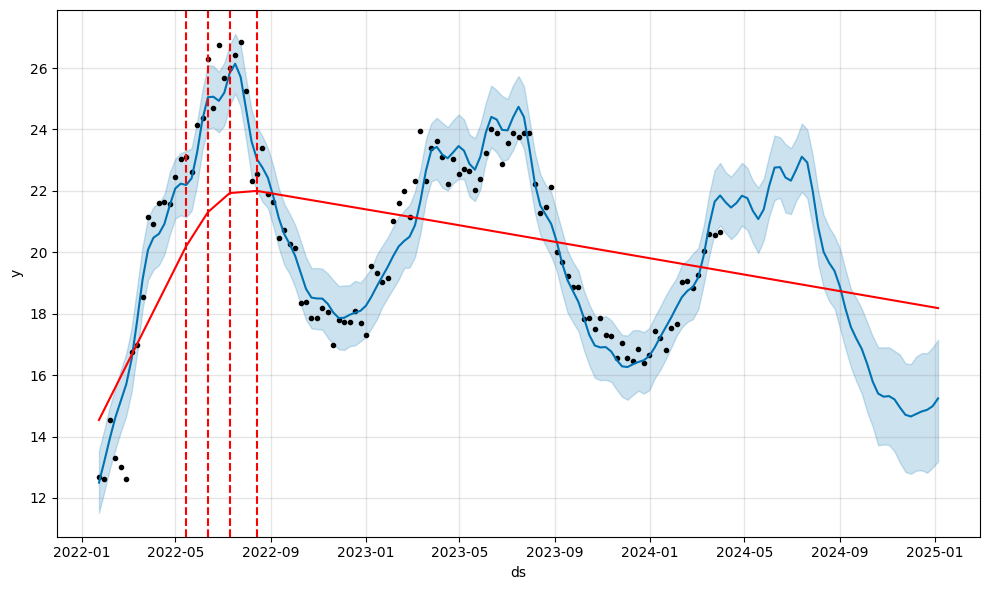

In [168]:
# We can change the inferred changepoint range by setting the changepoint_range
pro_change= Prophet(changepoint_range=0.9)
forecast = pro_change.fit(train_dataset).predict(future)
fig= pro_change.plot(forecast);
a = add_changepoints_to_plot(fig.gca(), pro_change, forecast)
plt.show()

22:15:49 - cmdstanpy - INFO - Chain [1] start processing
22:15:49 - cmdstanpy - INFO - Chain [1] done processing


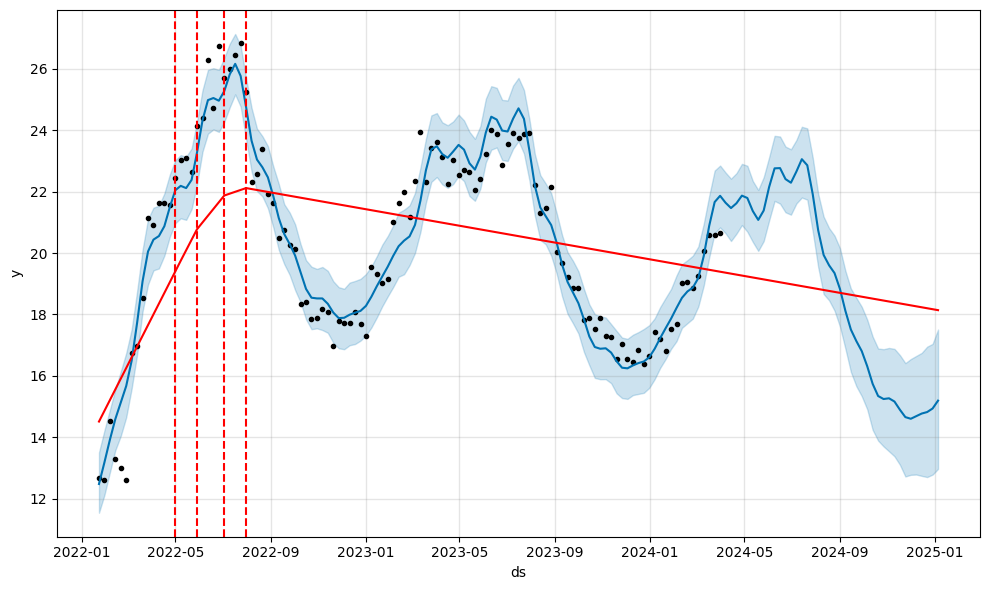

In [169]:
# The number of changepoints can be set by using the n_changepoints parameter when initializing prophet
pro_change= Prophet(n_changepoints=20, yearly_seasonality=True)
forecast = pro_change.fit(train_dataset).predict(future)
fig= pro_change.plot(forecast);
a = add_changepoints_to_plot(fig.gca(), pro_change, forecast)
plt.show()

### Adjusting Trend

Prophet allow you to adjust the trend in case there is an overfit (too much flexibility) or underfit (not enough flexibility). 

changepoint_prior_scale helps adjust the strength of the trend. The default value for changepoint_prior_scale is 0.05. 

Decrease the value to make the trend less flexible. Increase the value of changepoint_prior_scale to make the trend more flexible.

22:16:20 - cmdstanpy - INFO - Chain [1] start processing
22:16:20 - cmdstanpy - INFO - Chain [1] done processing


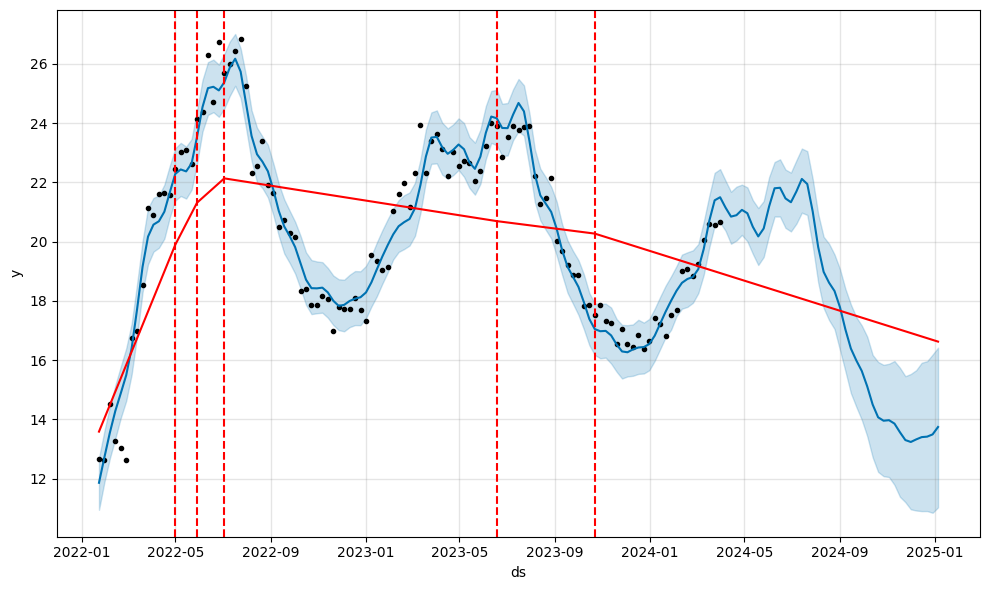

In [170]:
# Increasing the changepoint_prior_scale to 0.08 to make the trend flexible
pro_change= Prophet(n_changepoints=20, yearly_seasonality=True, changepoint_prior_scale=0.08)
forecast = pro_change.fit(train_dataset).predict(future)
fig= pro_change.plot(forecast);
a = add_changepoints_to_plot(fig.gca(), pro_change, forecast)
# Save the plot in "images" folder
plt.savefig("/Users/basazinbelhu/TimeSeries_Analysis_Prediction/images/prophet_changepoint_adjust_trend.png", bbox_inches="tight")
plt.show()

22:16:24 - cmdstanpy - INFO - Chain [1] start processing
22:16:24 - cmdstanpy - INFO - Chain [1] done processing
22:16:24 - cmdstanpy - ERROR - Chain [1] error: error during processing Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
22:16:24 - cmdstanpy - INFO - Chain [1] start processing
22:16:24 - cmdstanpy - INFO - Chain [1] done processing


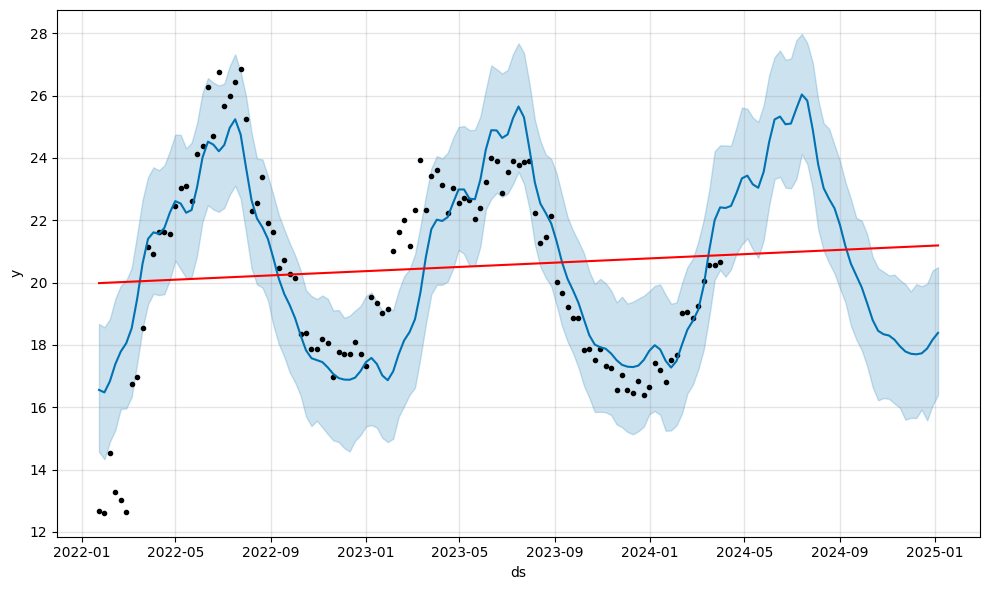

In [171]:
# Decreasing the changepoint_prior_scale to 0.001 to make the trend less flexible
pro_change= Prophet(n_changepoints=20, yearly_seasonality=True, changepoint_prior_scale=0.001)
forecast = pro_change.fit(train_dataset).predict(future)
fig= pro_change.plot(forecast);
a = add_changepoints_to_plot(fig.gca(), pro_change, forecast)
plt.show()

### Adding Holidays

Holidays and events can cause changes to a time series. In our example the National holidays  can impact sales of items in big stores.

We can create a custom holiday list for Prophet by creating a dataframe with two columns ds and holiday. A row for each occurrence of the holiday

In [172]:
holiday_season = pd.DataFrame({
  'holiday': 'holiday season',
  'ds': pd.to_datetime([
    # 2022
    '2022-01-01',  # New Year's Day
    '2022-07-04',  # July 4th (Independence Day)
    '2022-11-24',  # Thanksgiving
    '2022-11-25',  # Black Friday
    '2022-12-25',  # Christmas Day
    
    # 2023
    '2023-01-01',  # New Year's Day
    '2023-07-04',  # July 4th (Independence Day)
    '2023-11-23',  # Thanksgiving
    '2023-11-24',  # Black Friday
    '2023-12-25',  # Christmas Day
    
    # 2024
    '2024-01-01',  # New Year's Day
    '2024-07-04',  # July 4th (Independence Day)
    '2024-11-28',  # Thanksgiving
    '2024-11-29',  # Black Friday
    '2024-12-25'   # Christmas Day
]),
  'lower_window': -1,
  'upper_window': 0,
})

lower window and upper window extend holiday to days around the date. If we want to include a day prior to the national  holiday we set lower_window: -1 upper_window: 0

If we wanted to use the day after the holiday then set lower_window: 0 upper_window: 1

In [173]:
holiday_season

,holiday,ds,lower_window,upper_window
0,holiday season,2022-01-01,-1,0
1,holiday season,2022-07-04,-1,0
2,holiday season,2022-11-24,-1,0
3,holiday season,2022-11-25,-1,0
4,holiday season,2022-12-25,-1,0
5,holiday season,2023-01-01,-1,0
6,holiday season,2023-07-04,-1,0
7,holiday season,2023-11-23,-1,0
8,holiday season,2023-11-24,-1,0
9,holiday season,2023-12-25,-1,0


22:16:50 - cmdstanpy - INFO - Chain [1] start processing
22:16:50 - cmdstanpy - INFO - Chain [1] done processing


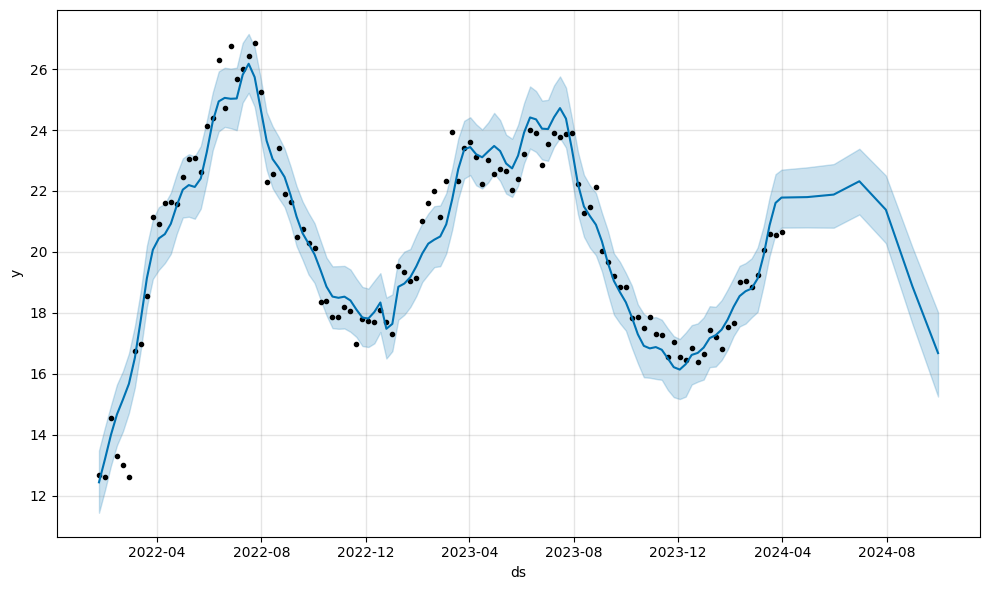

In [174]:
pro_holiday= Prophet(holidays=holiday_season)
pro_holiday.fit(train_dataset)
future_data = pro_holiday.make_future_dataframe(periods=6, freq = 'm')
 
# forecast the data for future data
forecast_data = pro_holiday.predict(future_data)
fig1 = pro_holiday.plot(forecast_data)
plt.savefig("/Users/basazinbelhu/TimeSeries_Analysis_Prediction/images/prophet_with_holiday.png", bbox_inches="tight")


plt.show()

### Adding Multiple Regressors

Additional regressors can be added to the Prophet model. This is done by using add_regressor. Additional regressor column value needs to be present in both the fitting as well as prediction dataframes.

22:17:11 - cmdstanpy - INFO - Chain [1] start processing
22:17:11 - cmdstanpy - INFO - Chain [1] done processing


Daily DF shape: (190757, 14)
Daily DF columns: Index(['sku', 'brand', 'segment', 'category', 'channel', 'region', 'pack_type',
       'price_unit', 'promotion_flag', 'delivery_days', 'stock_available',
       'delivered_qty', 'units_sold', 'date'],
      dtype='object')
Daily DF head:       sku     brand    segment category   channel      region  pack_type  \
0  MI-006  MiBrand1  Milk-Seg3     Milk    Retail  PL-Central  Multipack   
1  MI-006  MiBrand1  Milk-Seg3     Milk    Retail    PL-North     Single   
2  MI-006  MiBrand1  Milk-Seg3     Milk    Retail    PL-South     Carton   
3  MI-006  MiBrand1  Milk-Seg3     Milk  Discount  PL-Central     Single   
4  MI-006  MiBrand1  Milk-Seg3     Milk  Discount    PL-North     Single   

   price_unit  promotion_flag  delivery_days  stock_available  delivered_qty  \
0        2.38               0              1              141            128   
1        1.55               1              3                0            129   
2        4.00    

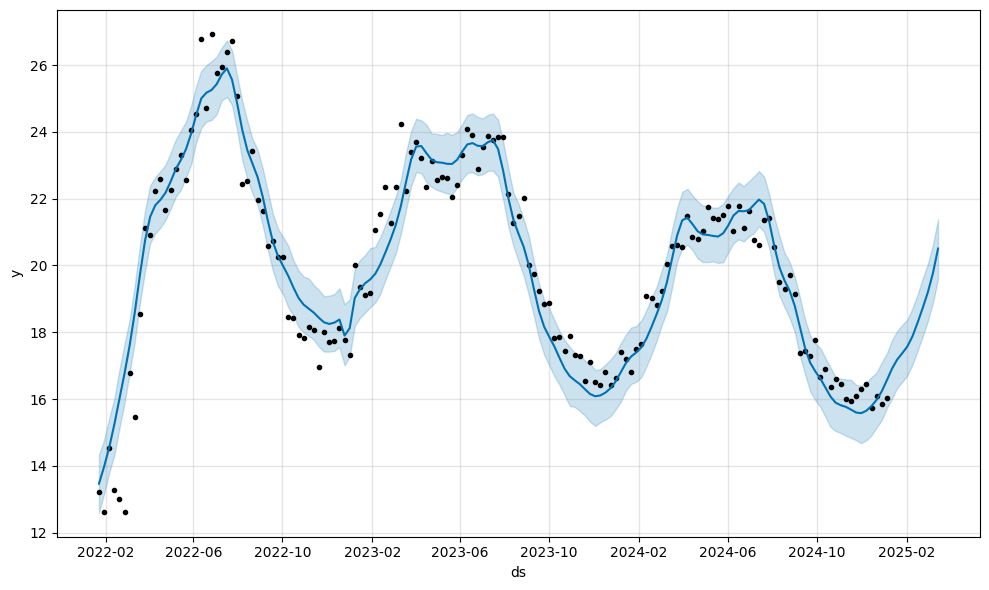

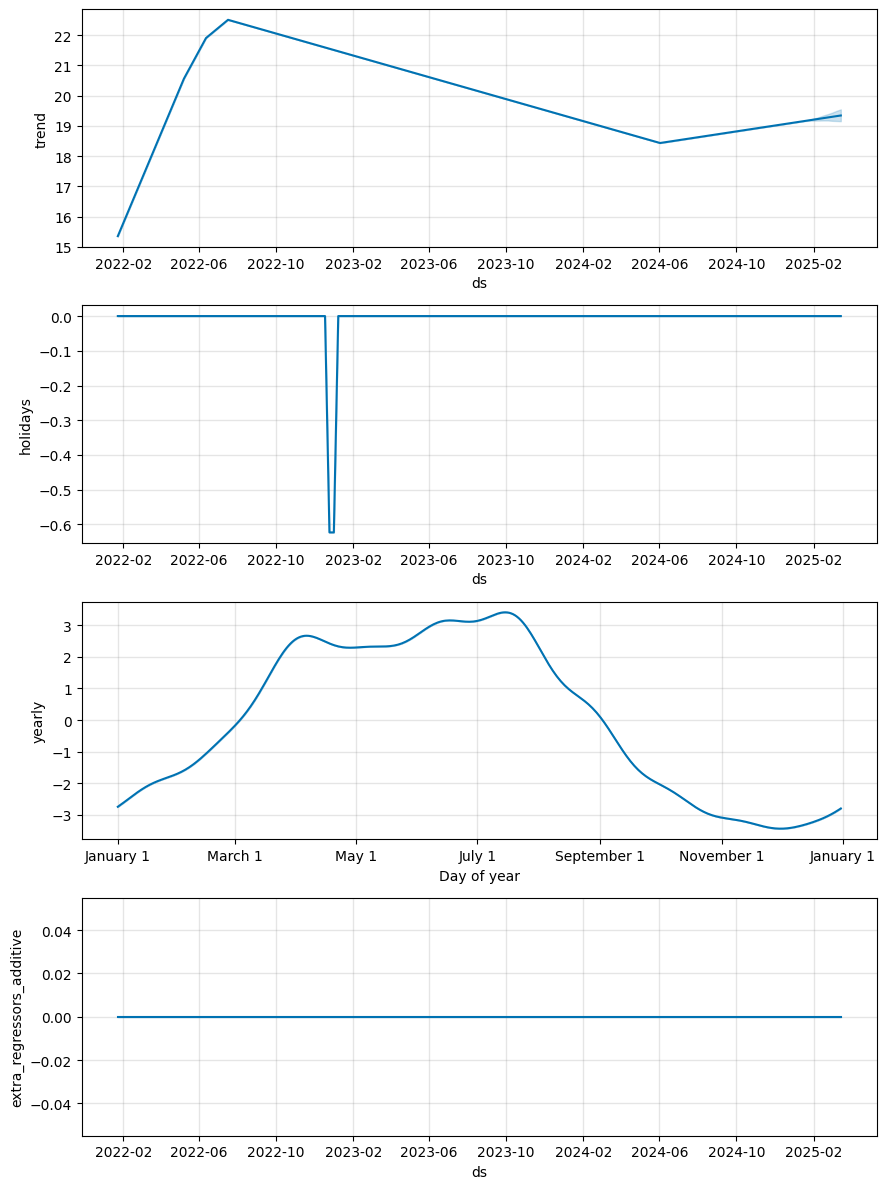

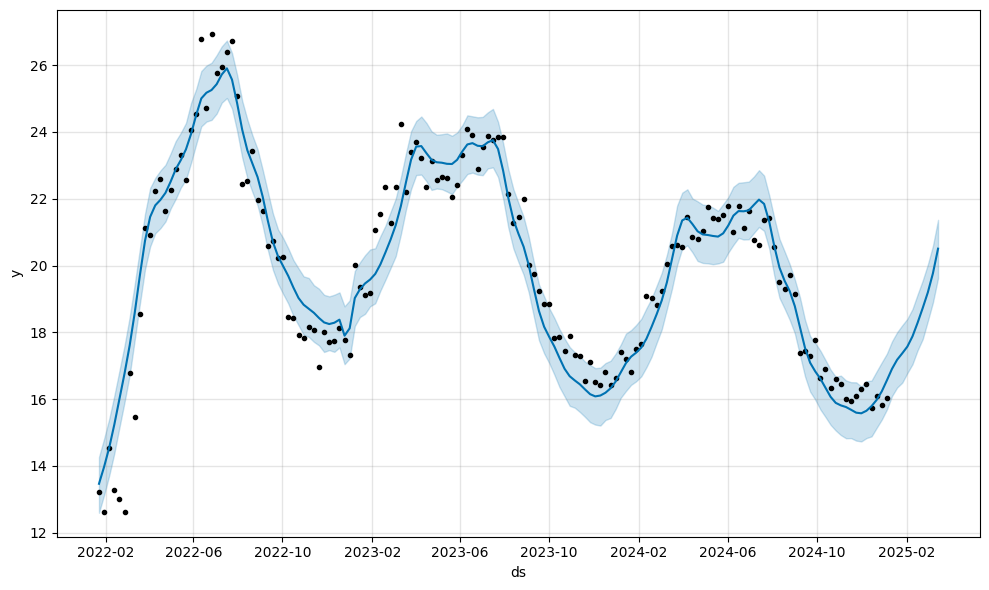

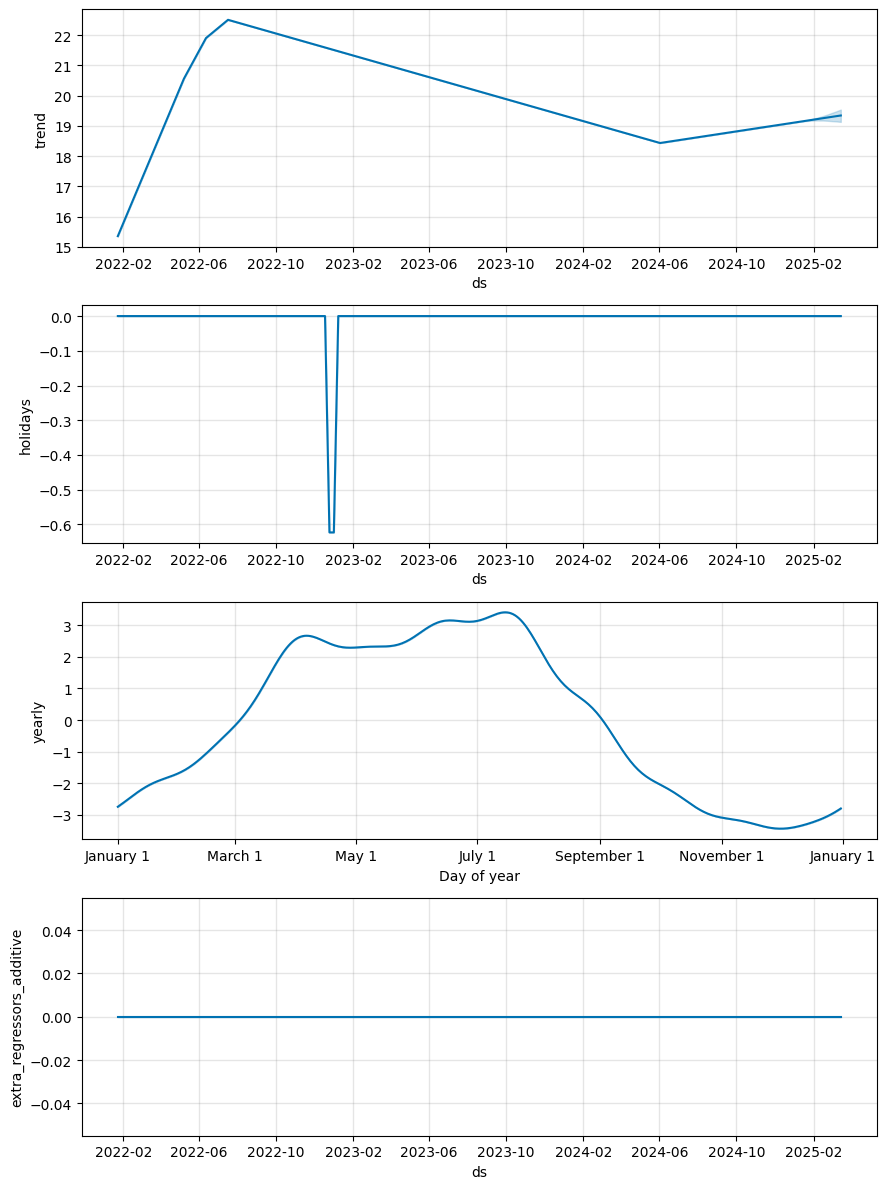

In [176]:
import pandas as pd
from prophet import Prophet

# Load daily data
df_daily = pd.read_csv('../input/FMCG_2022_2024.csv', index_col=0)
df_daily['date'] = pd.to_datetime(df_daily.index)  # Move index to column if date
df_daily = df_daily.reset_index(drop=True)
print("Daily DF shape:", df_daily.shape)
print("Daily DF columns:", df_daily.columns)
print("Daily DF head:", df_daily.head())
print("Daily DF NaNs:", df_daily.isna().sum())
print("Date range:", df_daily['date'].min(), "to", df_daily['date'].max())

# Aggregate to weekly (global)
df = df_daily.set_index('date').resample('W').agg({
    'units_sold': 'mean',  # avg_weekly_sales
    'price_unit': 'mean',
    'promotion_flag': 'mean',
    'delivery_days': 'mean',
    'stock_available': 'mean',
    'delivered_qty': 'sum'
}).reset_index()
df.rename(columns={'units_sold': 'avg_weekly_sales'}, inplace=True)
print("Weekly DF shape:", df.shape)
print("Weekly DF columns:", df.columns)
print("Weekly DF head:", df.head())
print("Weekly DF NaNs:", df.isna().sum())

# Prepare holidays (US as requested)
holidays = pd.DataFrame({
    'holiday': 'us_holiday',
    'ds': pd.to_datetime([
        # 2022
        '2022-01-01',  # New Year's Day
        '2022-07-04',  # July 4th (Independence Day)
        '2022-11-24',  # Thanksgiving
        '2022-11-25',  # Black Friday
        '2022-12-25',  # Christmas Day
        # 2023
        '2023-01-01',  # New Year's Day
        '2023-07-04',  # July 4th (Independence Day)
        '2023-11-23',  # Thanksgiving
        '2023-11-24',  # Black Friday
        '2023-12-25',  # Christmas Day
        # 2024
        '2024-01-01',  # New Year's Day
        '2024-07-04',  # July 4th (Independence Day)
        '2024-11-28',  # Thanksgiving
        '2024-11-29',  # Black Friday
        '2024-12-25'   # Christmas Day
    ]),
    'lower_window': 0,
    'upper_window': 1
})

# Prepare Prophet DataFrame
df_prophet = df[['date', 'avg_weekly_sales', 'price_unit', 'promotion_flag', 'delivery_days', 'stock_available', 'delivered_qty']].copy()
df_prophet.rename(columns={'date': 'ds', 'avg_weekly_sales': 'y'}, inplace=True)
df_prophet = df_prophet.dropna()
print("Prophet DF shape after dropna:", df_prophet.shape)
print("Prophet DF head after dropna:", df_prophet.head())
print("Prophet DF NaNs after dropna:", df_prophet.isna().sum())

if df_prophet.shape[0] < 2:
    print("Error: Insufficient rows for Prophet. Check if aggregation produced valid data or if CSV has entries.")
else:
    # Proceed with Prophet
    m = Prophet(holidays=holidays)
    m.add_regressor('price_unit')
    m.add_regressor('promotion_flag')
    m.add_regressor('delivery_days')
    m.add_regressor('stock_available')
    m.add_regressor('delivered_qty')
    
    m.fit(df_prophet)
    
    # Future (10 weeks)
    future = m.make_future_dataframe(periods=10, freq='W')
    future['price_unit'] = df_prophet['price_unit'].mean()
    future['promotion_flag'] = df_prophet['promotion_flag'].mean()
    future['delivery_days'] = df_prophet['delivery_days'].mean()
    future['stock_available'] = df_prophet['stock_available'].mean()
    future['delivered_qty'] = df_prophet['delivered_qty'].mean()
    
    forecast = m.predict(future)
    
    fig1 = m.plot(forecast)
    fig2 = m.plot_components(forecast)
    plt.savefig("/Users/basazinbelhu/TimeSeries_Analysis_Prediction/images/prophet_add_multi_regressor.png", bbox_inches="tight")

    plt.show()